# Материалы для приложений ВКР

Ноутбук собирает таблицы и графики для приложений А-Д. Он читает готовые артефакты из `results/nl2sql` и `data/nl2sql/synthetic_ecommerce`, не запускает инференс и не пересчитывает экспериментальные метрики.


In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent, cwd.parent.parent):
        if (candidate / 'nl2sql').exists() and (candidate / 'shared').exists():
            return candidate
    raise RuntimeError('Не удалось определить корень проекта.')


PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / 'results' / 'nl2sql'
DATA_DIR = PROJECT_ROOT / 'data' / 'nl2sql'
SEB_DIR = DATA_DIR / 'synthetic_ecommerce'

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 160)


def rel(path: Path) -> str:
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)


def show_note(text: str) -> None:
    display(Markdown(f'> {text}'))


def read_csv_or_empty(path: Path, label: str) -> pd.DataFrame:
    if not path.exists():
        show_note(f'Файл не найден: `{rel(path)}`. Таблица "{label}" пропущена.')
        return pd.DataFrame()
    return pd.read_csv(path)


def read_json_or_empty(path: Path, label: str) -> dict:
    if not path.exists():
        show_note(f'Файл не найден: `{rel(path)}`. Блок "{label}" пропущен.')
        return {}
    with path.open('r', encoding='utf-8') as handle:
        return json.load(handle)


def display_table(title: str, df: pd.DataFrame, round_digits: int | None = None) -> None:
    display(Markdown(f'**{title}**'))
    if df.empty:
        show_note('Нет данных для отображения.')
        return
    out = df.copy()
    if round_digits is not None:
        numeric_cols = out.select_dtypes(include='number').columns
        out[numeric_cols] = out[numeric_cols].round(round_digits)
    display(out.style.hide(axis='index'))


def display_png(title: str, path: Path, width: int = 980) -> None:
    display(Markdown(f'**{title}**'))
    if not path.exists():
        show_note(f'Файл изображения не найден: `{rel(path)}`.')
        return
    show_note(f'Источник: `{rel(path)}`')
    display(Image(filename=str(path), width=width))


def compact_metric_table(df: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    cols = ['model_display_name', 'benchmark', 'n_samples', *metrics]
    out = df[[col for col in cols if col in df.columns]].copy()
    return out.rename(columns={
        'model_display_name': 'Модель',
        'benchmark': 'Бенчмарк',
        'n_samples': 'N',
        'execution_accuracy': 'EA',
        'execution_accuracy_q05': 'EA q05',
        'execution_accuracy_q50': 'EA q50',
        'execution_accuracy_q95': 'EA q95',
        'pass@1': 'Pass@1',
        'pass@3': 'Pass@3',
        'pass@5': 'Pass@5',
        'Tinf': 'Tinf, мс',
        'Tok': 'Токены',
        'Cost': 'Стоимость, $',
        'Eff': 'Eff',
        'Eff_normalized': 'Eff norm',
    })


ea_summary = read_csv_or_empty(RESULTS_DIR / 'metrics' / 'ea' / 'summary_metrics.csv', 'EA summary')
ea_samples = read_csv_or_empty(RESULTS_DIR / 'metrics' / 'ea' / 'sample_metrics.csv', 'EA sample metrics')
pass_summary = read_csv_or_empty(RESULTS_DIR / 'metrics' / 'pass_k' / 'summary_metrics.csv', 'Pass@K summary')
coverage = read_json_or_empty(SEB_DIR / 'coverage_summary.json', 'SEB coverage summary')
dataset = read_json_or_empty(SEB_DIR / 'dataset_v1.json', 'SEB dataset')
edge_cases = read_json_or_empty(SEB_DIR / 'edge_cases_v1.json', 'SEB edge cases')

show_note(f'Корень проекта: `{PROJECT_ROOT}`')
show_note(f'Основной каталог результатов: `{rel(RESULTS_DIR)}`')


> Корень проекта: `/home/count/code/vkr`

> Основной каталог результатов: `results/nl2sql`

## Приложение А. Структура программной реализации экспериментального стенда


In [2]:
display_table('Таблица А.1 — Структура каталогов экспериментального стенда', pd.DataFrame([
    {'Раздел': 'shared/', 'Назначение': 'Общая инфраструктура: конфигурации, API/Ollama backend, статистика, logging/progress.'},
    {'Раздел': 'nl2sql/', 'Назначение': 'Домен NL2SQL: подготовка, inference, execution-based оценка, аналитические ноутбуки.'},
    {'Раздел': 'data/nl2sql/', 'Назначение': 'Входные данные Spider, BIRD и локальный synthetic_ecommerce benchmark.'},
    {'Раздел': 'results/nl2sql/raw/', 'Назначение': 'Сырые JSONL-ответы моделей и служебные данные inference.'},
    {'Раздел': 'results/nl2sql/metrics/', 'Назначение': 'Агрегированные и sample-level метрики для режимов ea и pass_k.'},
    {'Раздел': 'results/nl2sql/figures/', 'Назначение': 'Готовые графики для анализа и переноса в текст ВКР.'},
    {'Раздел': 'results/nl2sql/synthetic_benchmark/', 'Назначение': 'Результаты локального SEB-сценария.'},
]))

display_table('Таблица А.2 — Основные исполняемые компоненты стенда', pd.DataFrame([
    {'Компонент': 'nl2sql/scripts/02_run_inference.py', 'Назначение': 'Генерация SQL-кандидатов выбранной моделью.'},
    {'Компонент': 'nl2sql/scripts/03_evaluate.py', 'Назначение': 'Execution-based оценка raw JSONL и сборка CSV-метрик.'},
    {'Компонент': 'nl2sql/scripts/04_archive_results.py', 'Назначение': 'Архивация результатов перед новыми запусками.'},
    {'Компонент': 'nl2sql/scripts/07_prepare_synthetic_ecommerce.py', 'Назначение': 'Подготовка локального synthetic_ecommerce набора.'},
    {'Компонент': 'nl2sql/scripts/08_validate_synthetic_ecommerce.py', 'Назначение': 'Валидация SEB-сценария и исполнимости SQL.'},
    {'Компонент': 'benchmark_nl2sql.py', 'Назначение': 'Локальный запуск synthetic benchmark в режимах ea/pass_k.'},
]))

display_table('Таблица А.3 — Конфигурационные файлы эксперимента', pd.DataFrame([
    {'Файл': 'shared/configs/models.yaml', 'Назначение': 'Единый каталог моделей, backend, pricing и доменные override-параметры.'},
    {'Файл': 'nl2sql/configs/experiment.yaml', 'Назначение': 'Пути, режимы, значения k и общие параметры эксперимента.'},
    {'Файл': 'nl2sql/configs/metrics.yaml', 'Назначение': 'Параметры статистики, bootstrap и расчёта метрик.'},
]))

display_table('Таблица А.4 — Форматы сохраняемых экспериментальных артефактов', pd.DataFrame([
    {'Путь': 'results/nl2sql/raw/*.jsonl', 'Содержимое': 'Сырые ответы моделей, кандидаты SQL, latency/tokens/cost metadata.'},
    {'Путь': 'results/nl2sql/metrics/ea/summary_metrics.csv', 'Содержимое': 'Сводные метрики режима Execution Accuracy.'},
    {'Путь': 'results/nl2sql/metrics/ea/sample_metrics.csv', 'Содержимое': 'Метрики и исходы на уровне отдельных примеров EA.'},
    {'Путь': 'results/nl2sql/metrics/pass_k/summary_metrics.csv', 'Содержимое': 'Сводные Pass@K-метрики.'},
    {'Путь': 'results/nl2sql/metrics/pass_k/sample_metrics.csv', 'Содержимое': 'Sample-level исходы для многократной генерации.'},
    {'Путь': 'results/nl2sql/figures/**/*.png', 'Содержимое': 'Готовые графики для отчёта.'},
    {'Путь': 'results/nl2sql/synthetic_benchmark/**/results.json', 'Содержимое': 'Результаты локального SEB-сценария.'},
]))


**Таблица А.1 — Структура каталогов экспериментального стенда**

Раздел,Назначение
shared/,"Общая инфраструктура: конфигурации, API/Ollama backend, статистика, logging/progress."
nl2sql/,"Домен NL2SQL: подготовка, inference, execution-based оценка, аналитические ноутбуки."
data/nl2sql/,"Входные данные Spider, BIRD и локальный synthetic_ecommerce benchmark."
results/nl2sql/raw/,Сырые JSONL-ответы моделей и служебные данные inference.
results/nl2sql/metrics/,Агрегированные и sample-level метрики для режимов ea и pass_k.
results/nl2sql/figures/,Готовые графики для анализа и переноса в текст ВКР.
results/nl2sql/synthetic_benchmark/,Результаты локального SEB-сценария.


**Таблица А.2 — Основные исполняемые компоненты стенда**

Компонент,Назначение
nl2sql/scripts/02_run_inference.py,Генерация SQL-кандидатов выбранной моделью.
nl2sql/scripts/03_evaluate.py,Execution-based оценка raw JSONL и сборка CSV-метрик.
nl2sql/scripts/04_archive_results.py,Архивация результатов перед новыми запусками.
nl2sql/scripts/07_prepare_synthetic_ecommerce.py,Подготовка локального synthetic_ecommerce набора.
nl2sql/scripts/08_validate_synthetic_ecommerce.py,Валидация SEB-сценария и исполнимости SQL.
benchmark_nl2sql.py,Локальный запуск synthetic benchmark в режимах ea/pass_k.


**Таблица А.3 — Конфигурационные файлы эксперимента**

Файл,Назначение
shared/configs/models.yaml,"Единый каталог моделей, backend, pricing и доменные override-параметры."
nl2sql/configs/experiment.yaml,"Пути, режимы, значения k и общие параметры эксперимента."
nl2sql/configs/metrics.yaml,"Параметры статистики, bootstrap и расчёта метрик."


**Таблица А.4 — Форматы сохраняемых экспериментальных артефактов**

Путь,Содержимое
results/nl2sql/raw/*.jsonl,"Сырые ответы моделей, кандидаты SQL, latency/tokens/cost metadata."
results/nl2sql/metrics/ea/summary_metrics.csv,Сводные метрики режима Execution Accuracy.
results/nl2sql/metrics/ea/sample_metrics.csv,Метрики и исходы на уровне отдельных примеров EA.
results/nl2sql/metrics/pass_k/summary_metrics.csv,Сводные Pass@K-метрики.
results/nl2sql/metrics/pass_k/sample_metrics.csv,Sample-level исходы для многократной генерации.
results/nl2sql/figures/**/*.png,Готовые графики для отчёта.
results/nl2sql/synthetic_benchmark/**/results.json,Результаты локального SEB-сценария.


## Приложение Б. Структура синтетического набора данных SEB


**Таблица Б.1 — Файлы синтетического набора SEB**

Файл,Назначение,Путь
dataset_v1.json,Основная схема и ядро SQL-запросов.,data/nl2sql/synthetic_ecommerce/dataset_v1.json
edge_cases_v1.json,Дополнительные edge-case SQL-сценарии.,data/nl2sql/synthetic_ecommerce/edge_cases_v1.json
seed.sql,SQL-скрипт заполнения SQLite snapshot.,data/nl2sql/synthetic_ecommerce/seed.sql
snapshot.sqlite,Готовая исполняемая SQLite-база.,data/nl2sql/synthetic_ecommerce/snapshot.sqlite
coverage_summary.json,"Сводка покрытия схемы, запросов и особенностей данных.",data/nl2sql/synthetic_ecommerce/coverage_summary.json


**Таблица Б.2 — Размер таблиц SEB**

Таблица,Количество строк
customers,420
categories,24
products,220
orders,720
order_items,1440
returns,180


**Таблица Б.3 — Реляционная схема SEB**

...

Пользовательское намерение,Количество запросов
aggregation,21
comparison,12
filtering,23
ranking,5
segmentation,20


**Таблица Б.10 — Использование таблиц в SQL-запросах SEB**

Таблица,Количество использований
orders,20
order_items,17
products,15
customers,15
returns,8
categories,3


**Рисунок Б.1 — Распределение SQL-запросов SEB по сложности**

> Источник: `results/nl2sql/synthetic_benchmark/figures/synthetic_analysis/seb_dataset_difficulty_ru.png`

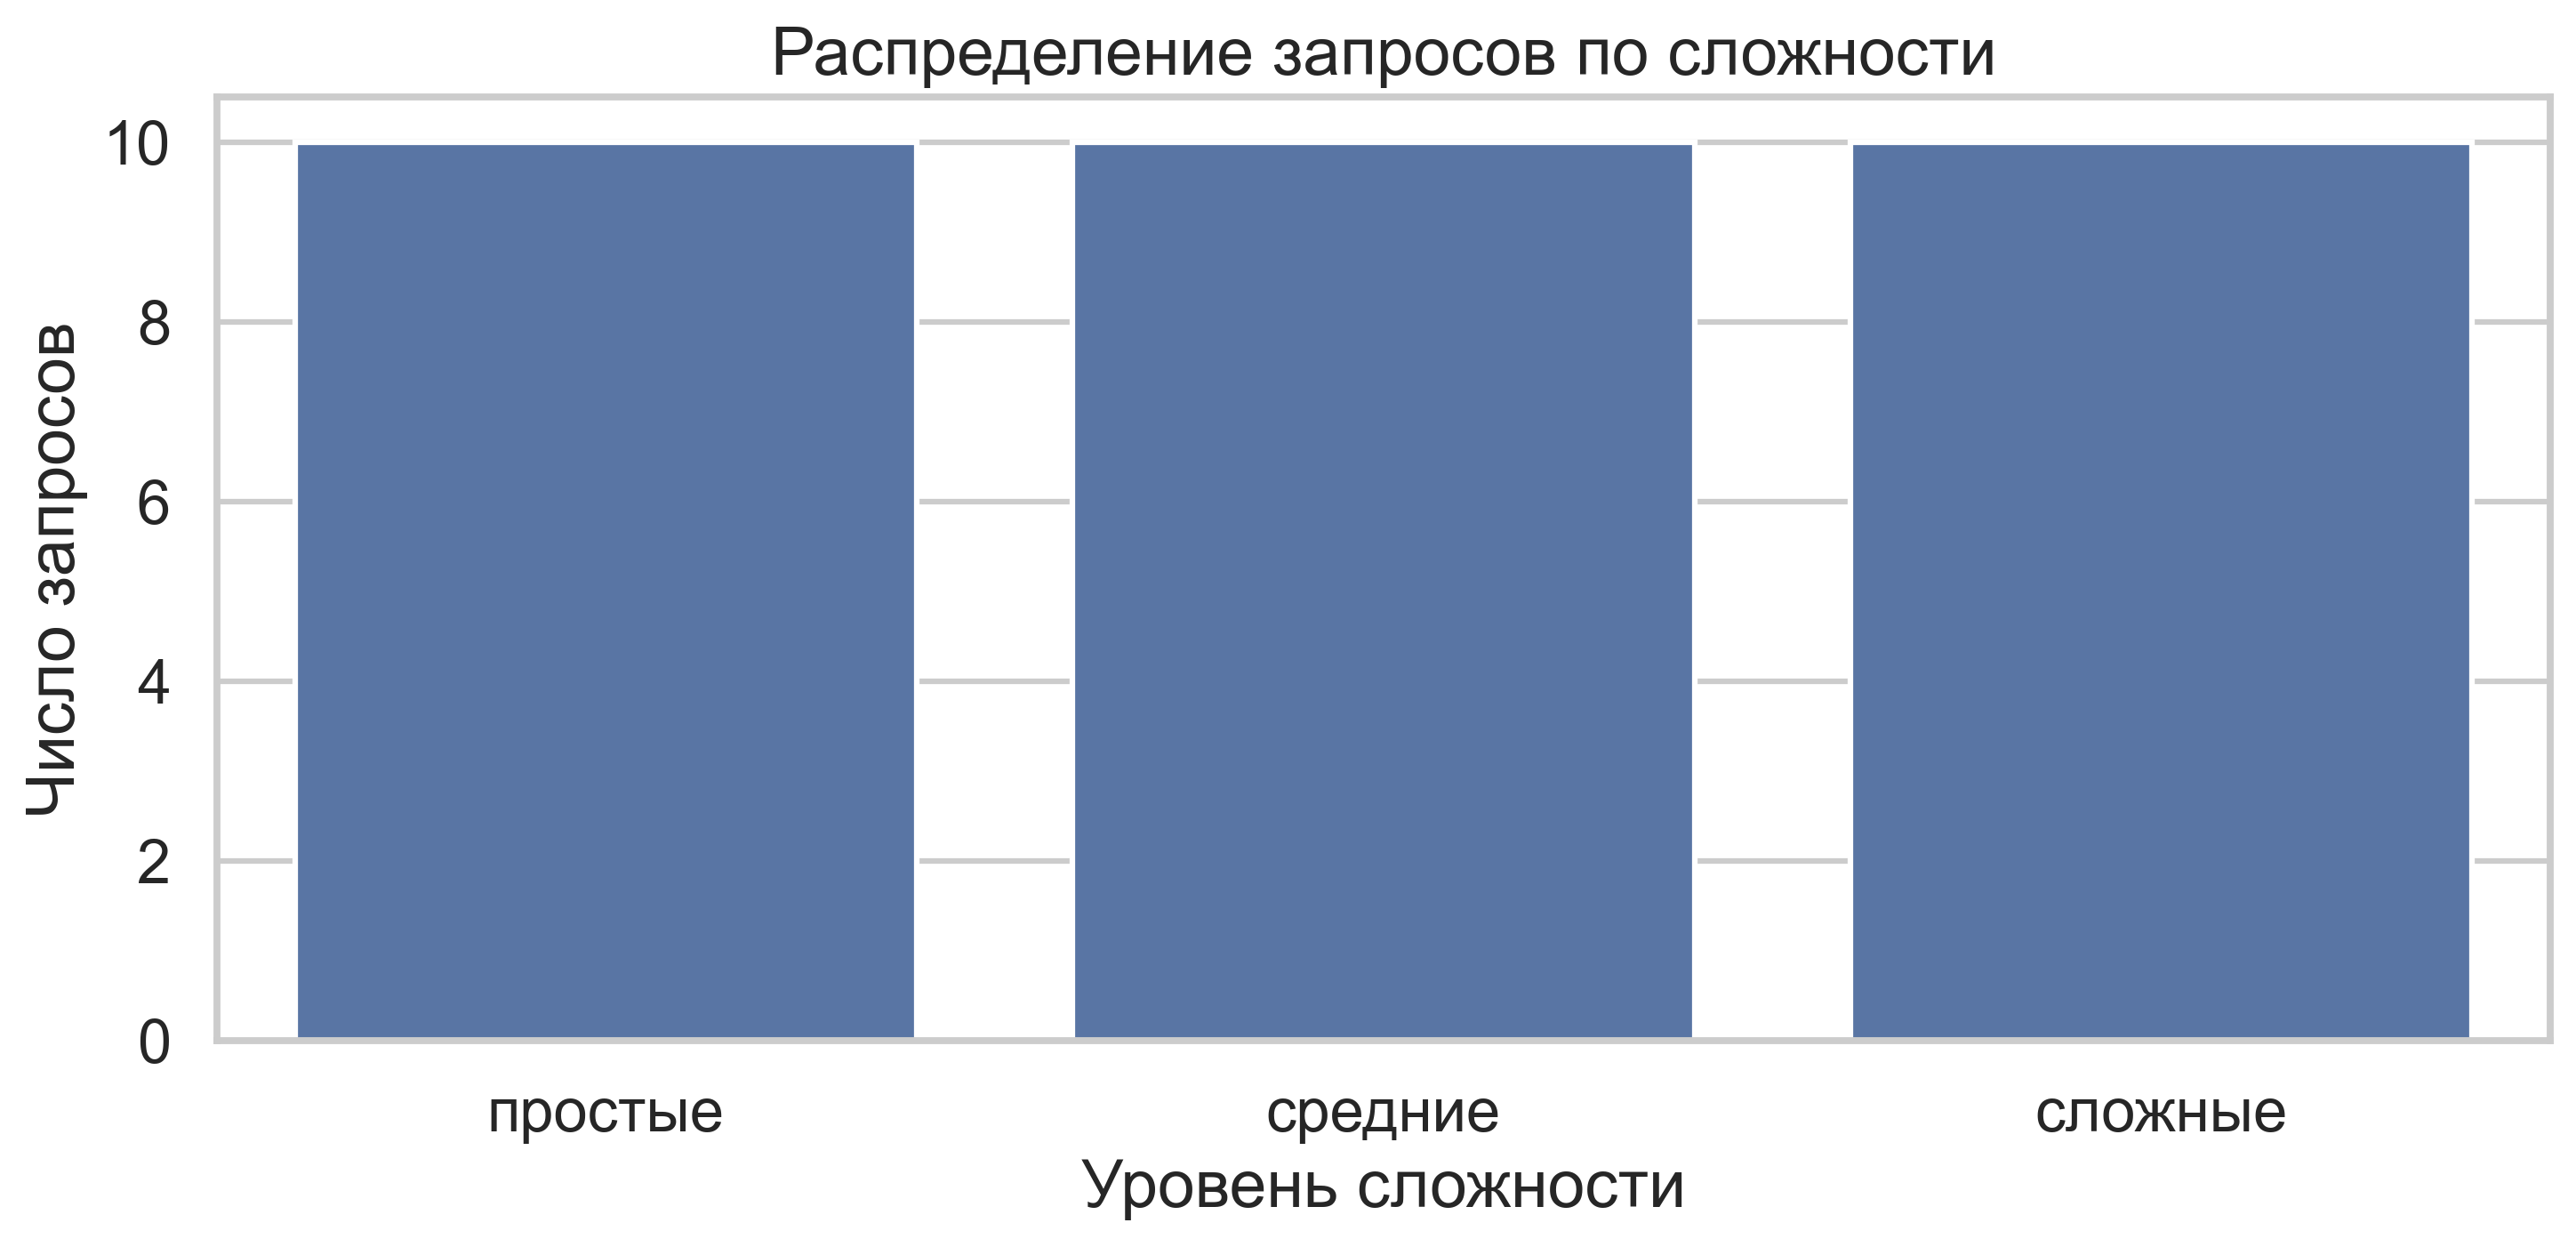

**Рисунок Б.2 — Распределение длины вопросов SEB**

> Источник: `results/nl2sql/synthetic_benchmark/figures/synthetic_analysis/seb_question_length_ru.png`

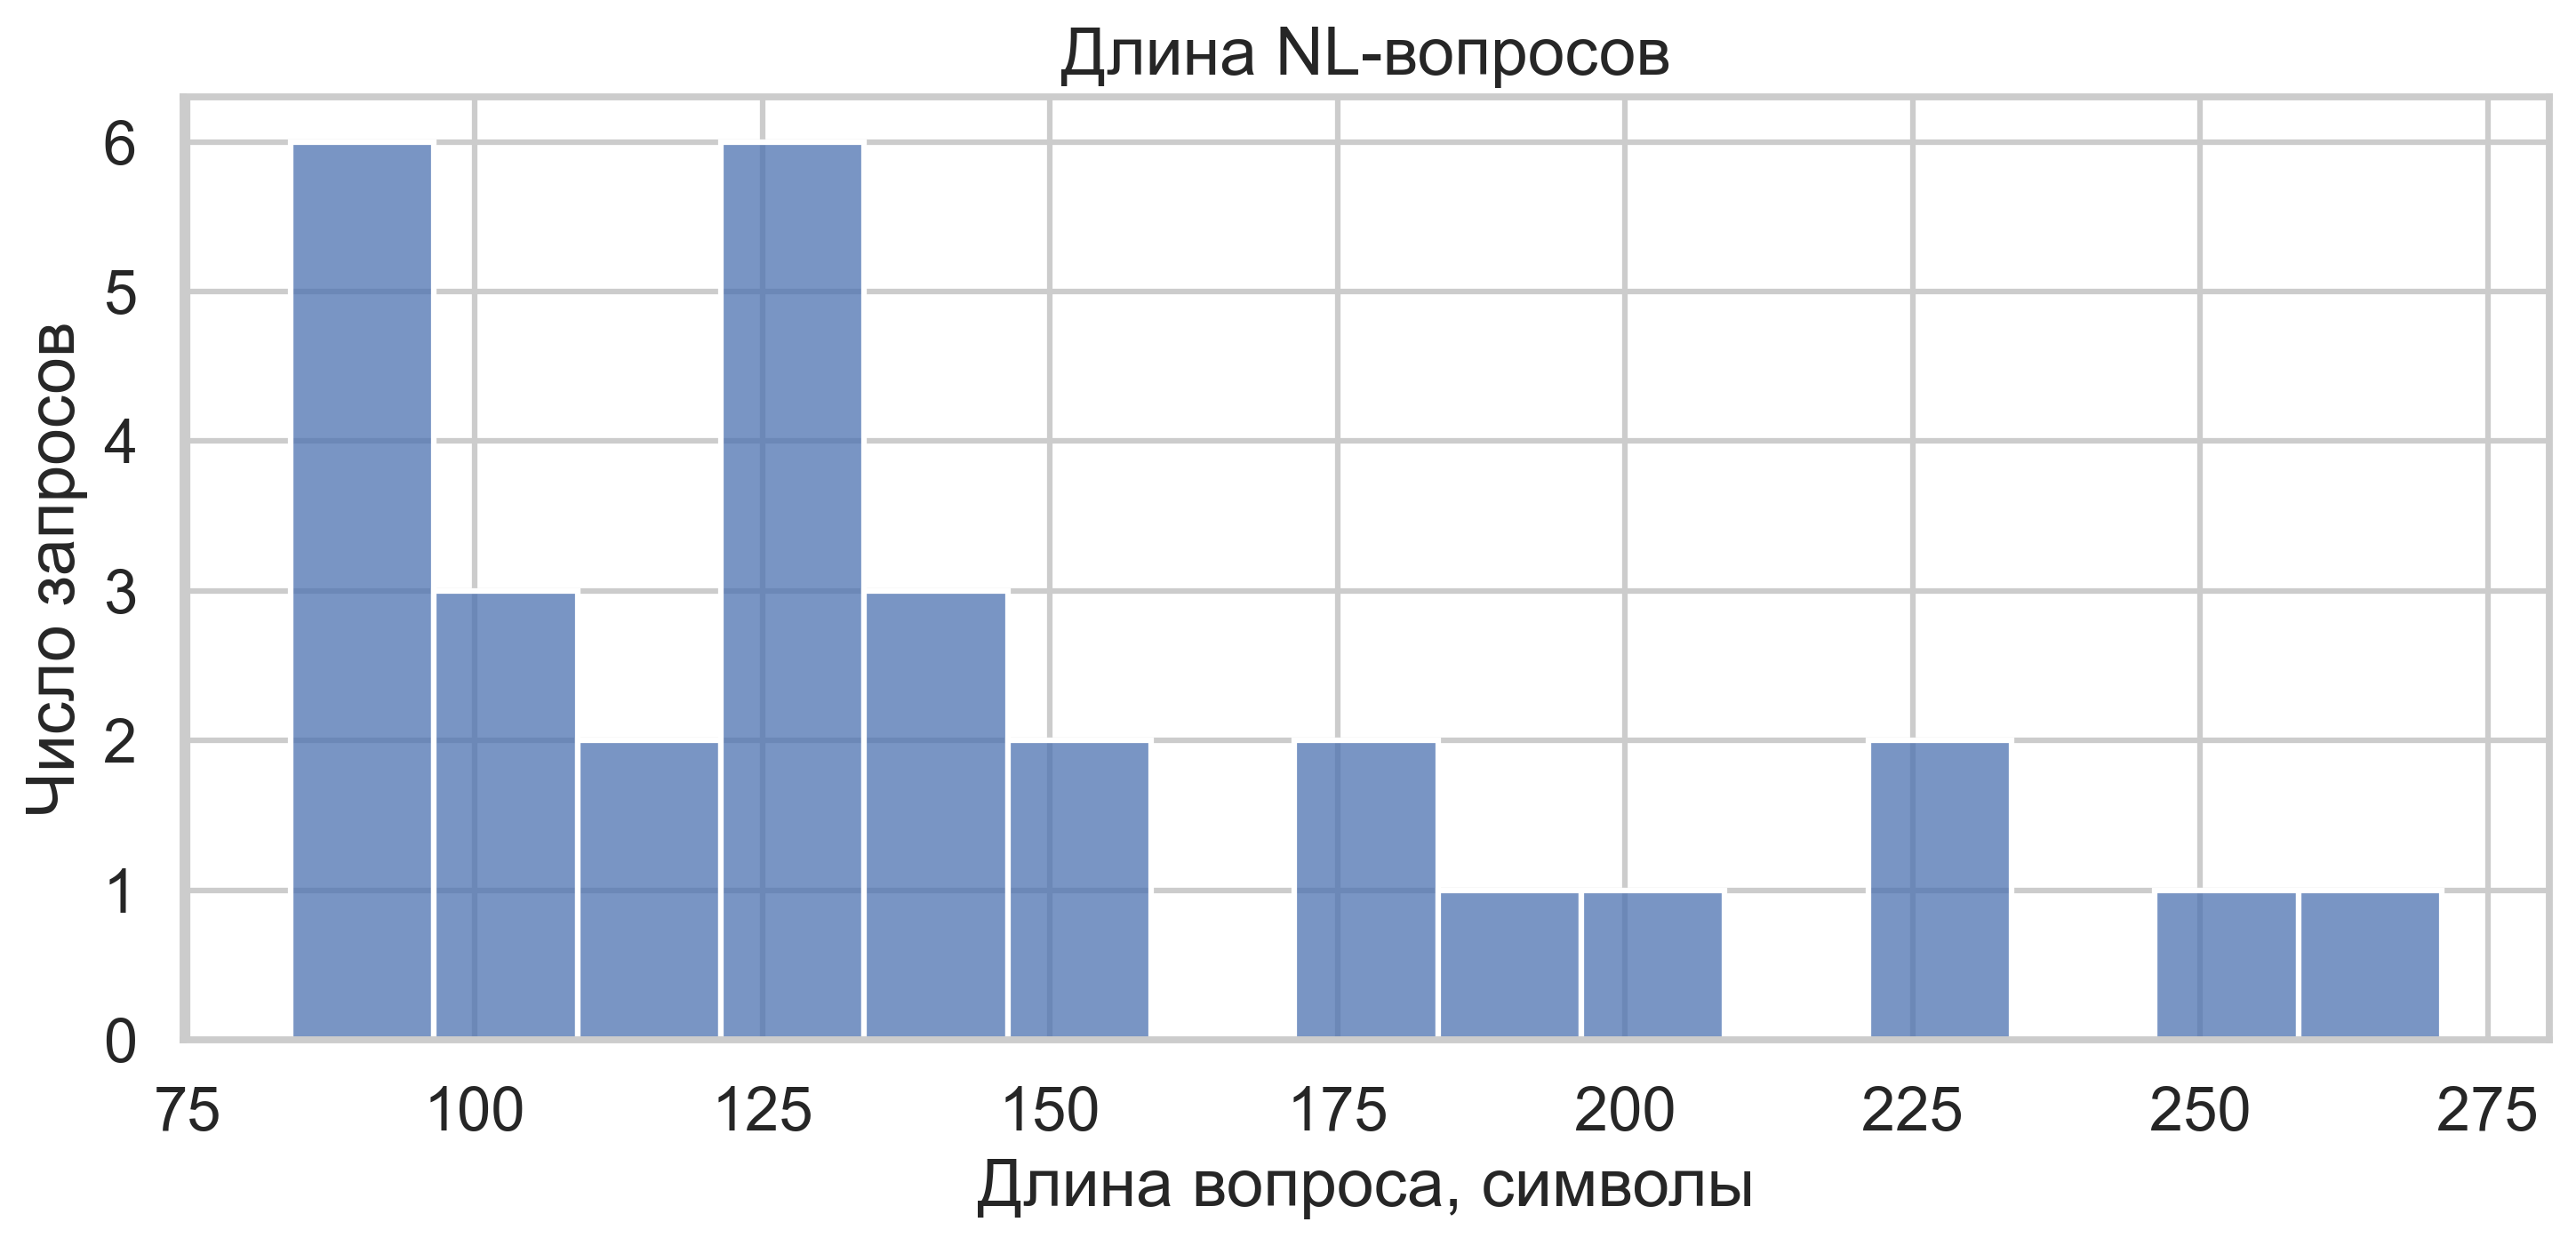

**Рисунок Б.3 — Распределение длины эталонных SQL-запросов SEB**

> Источник: `results/nl2sql/synthetic_benchmark/figures/synthetic_analysis/seb_gold_sql_length_ru.png`

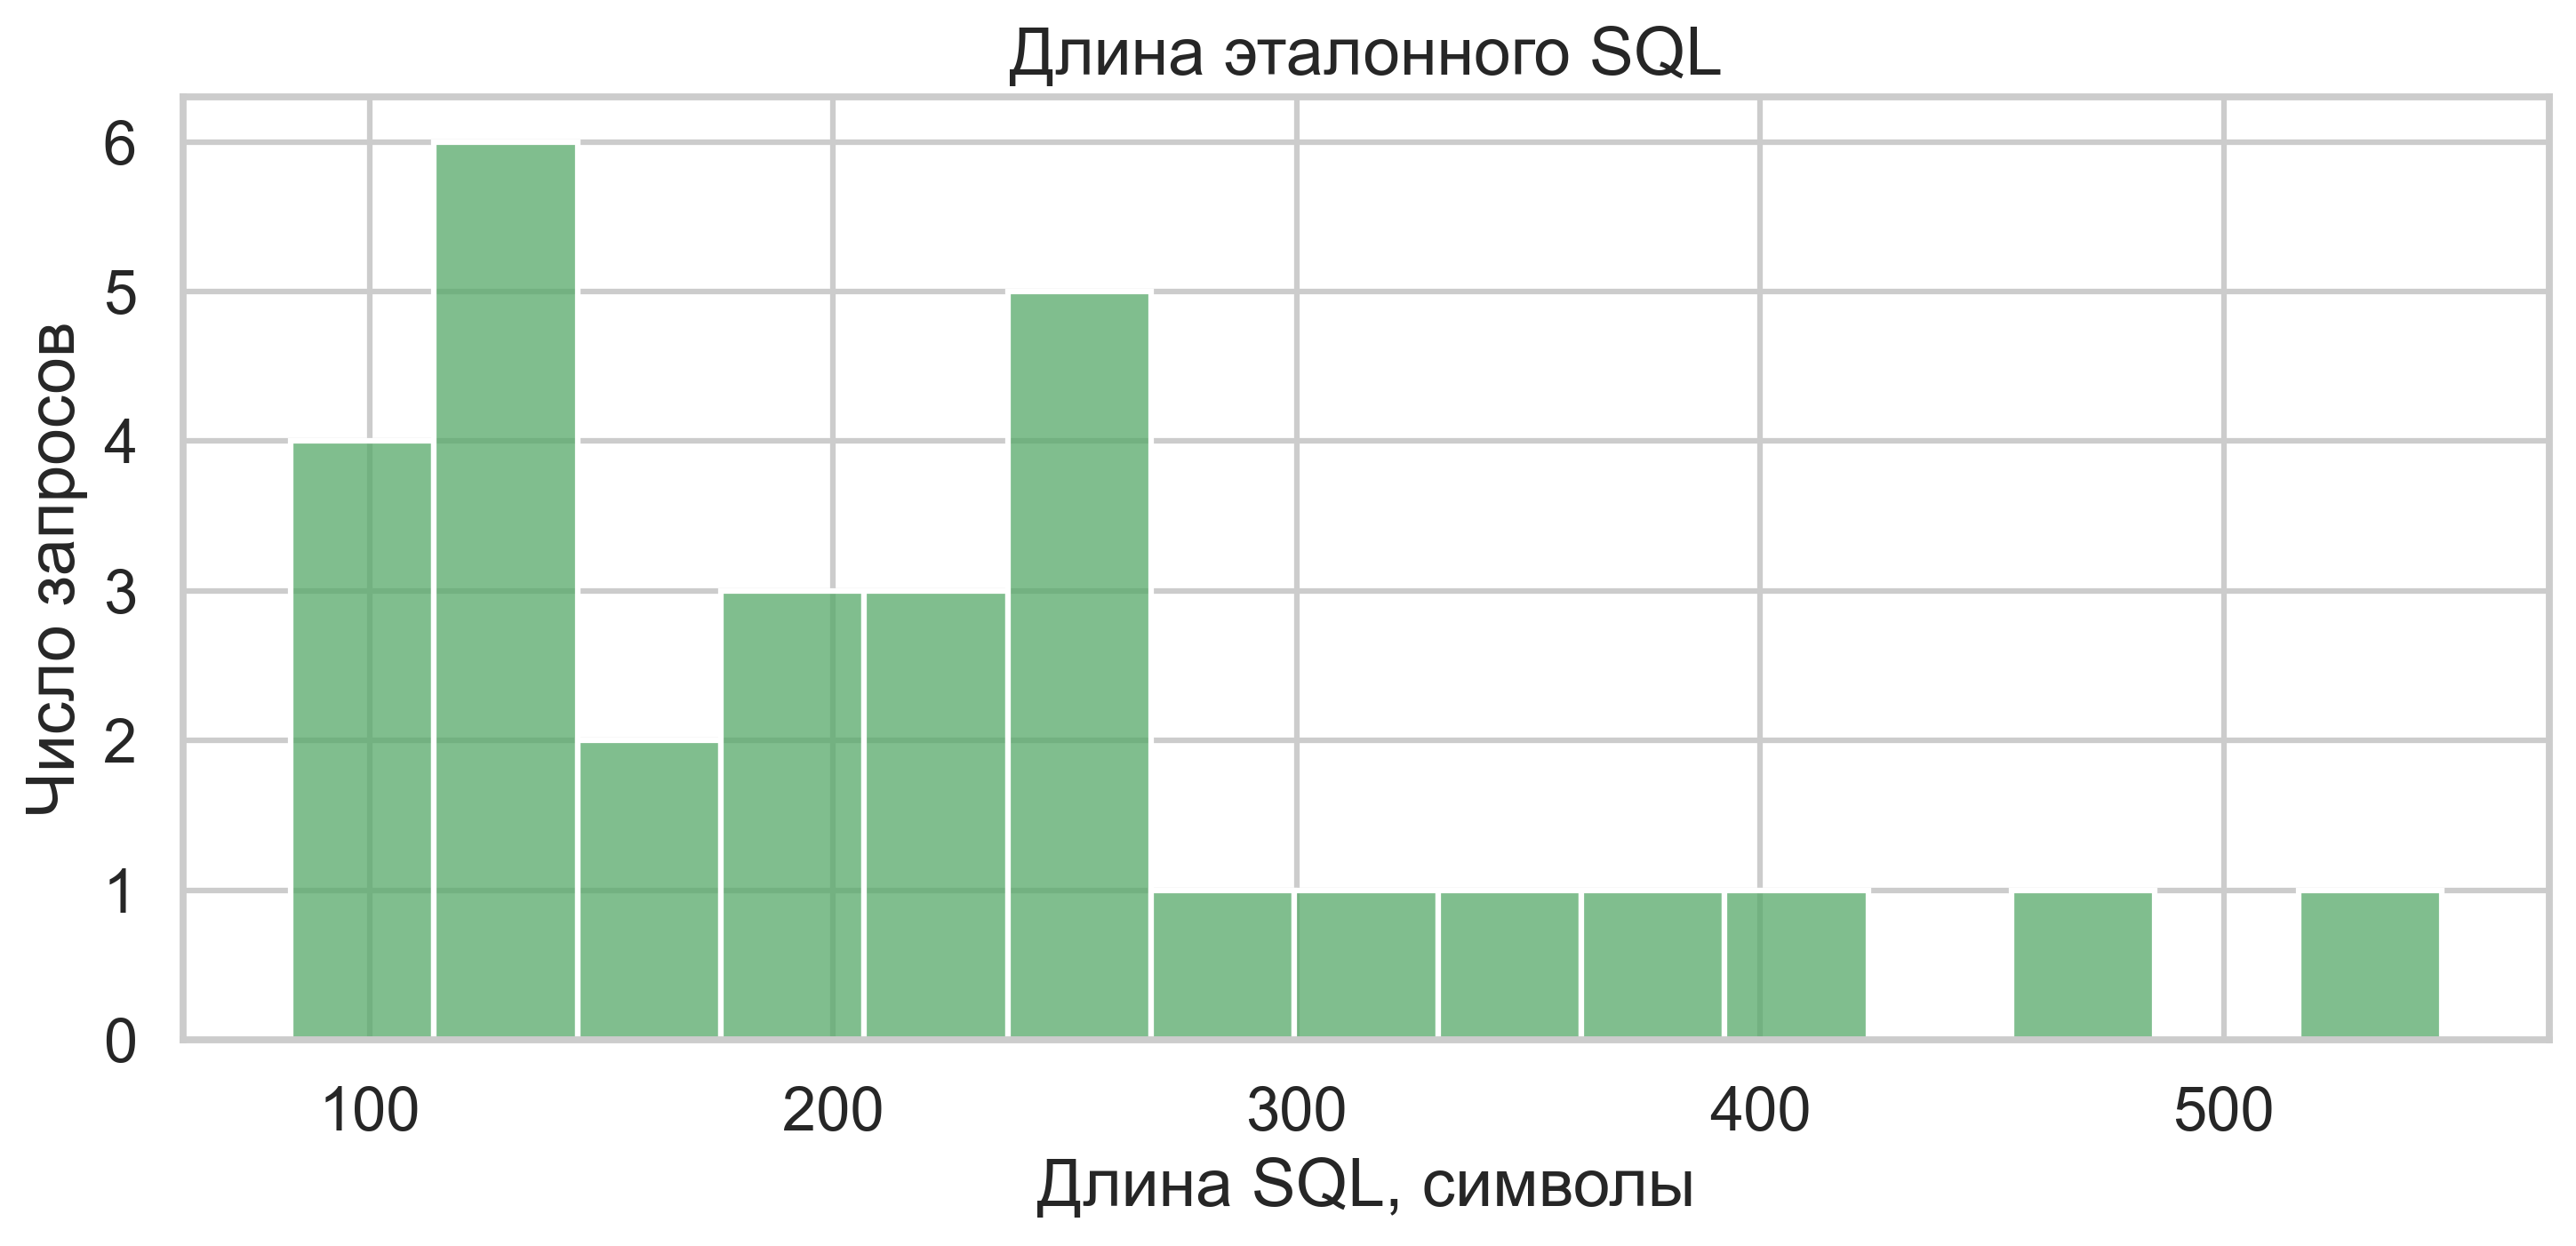

**Рисунок Б.4 — Execution Accuracy моделей на SEB**

> Источник: `results/nl2sql/synthetic_benchmark/figures/synthetic_analysis/seb_ea_overall_ru.png`

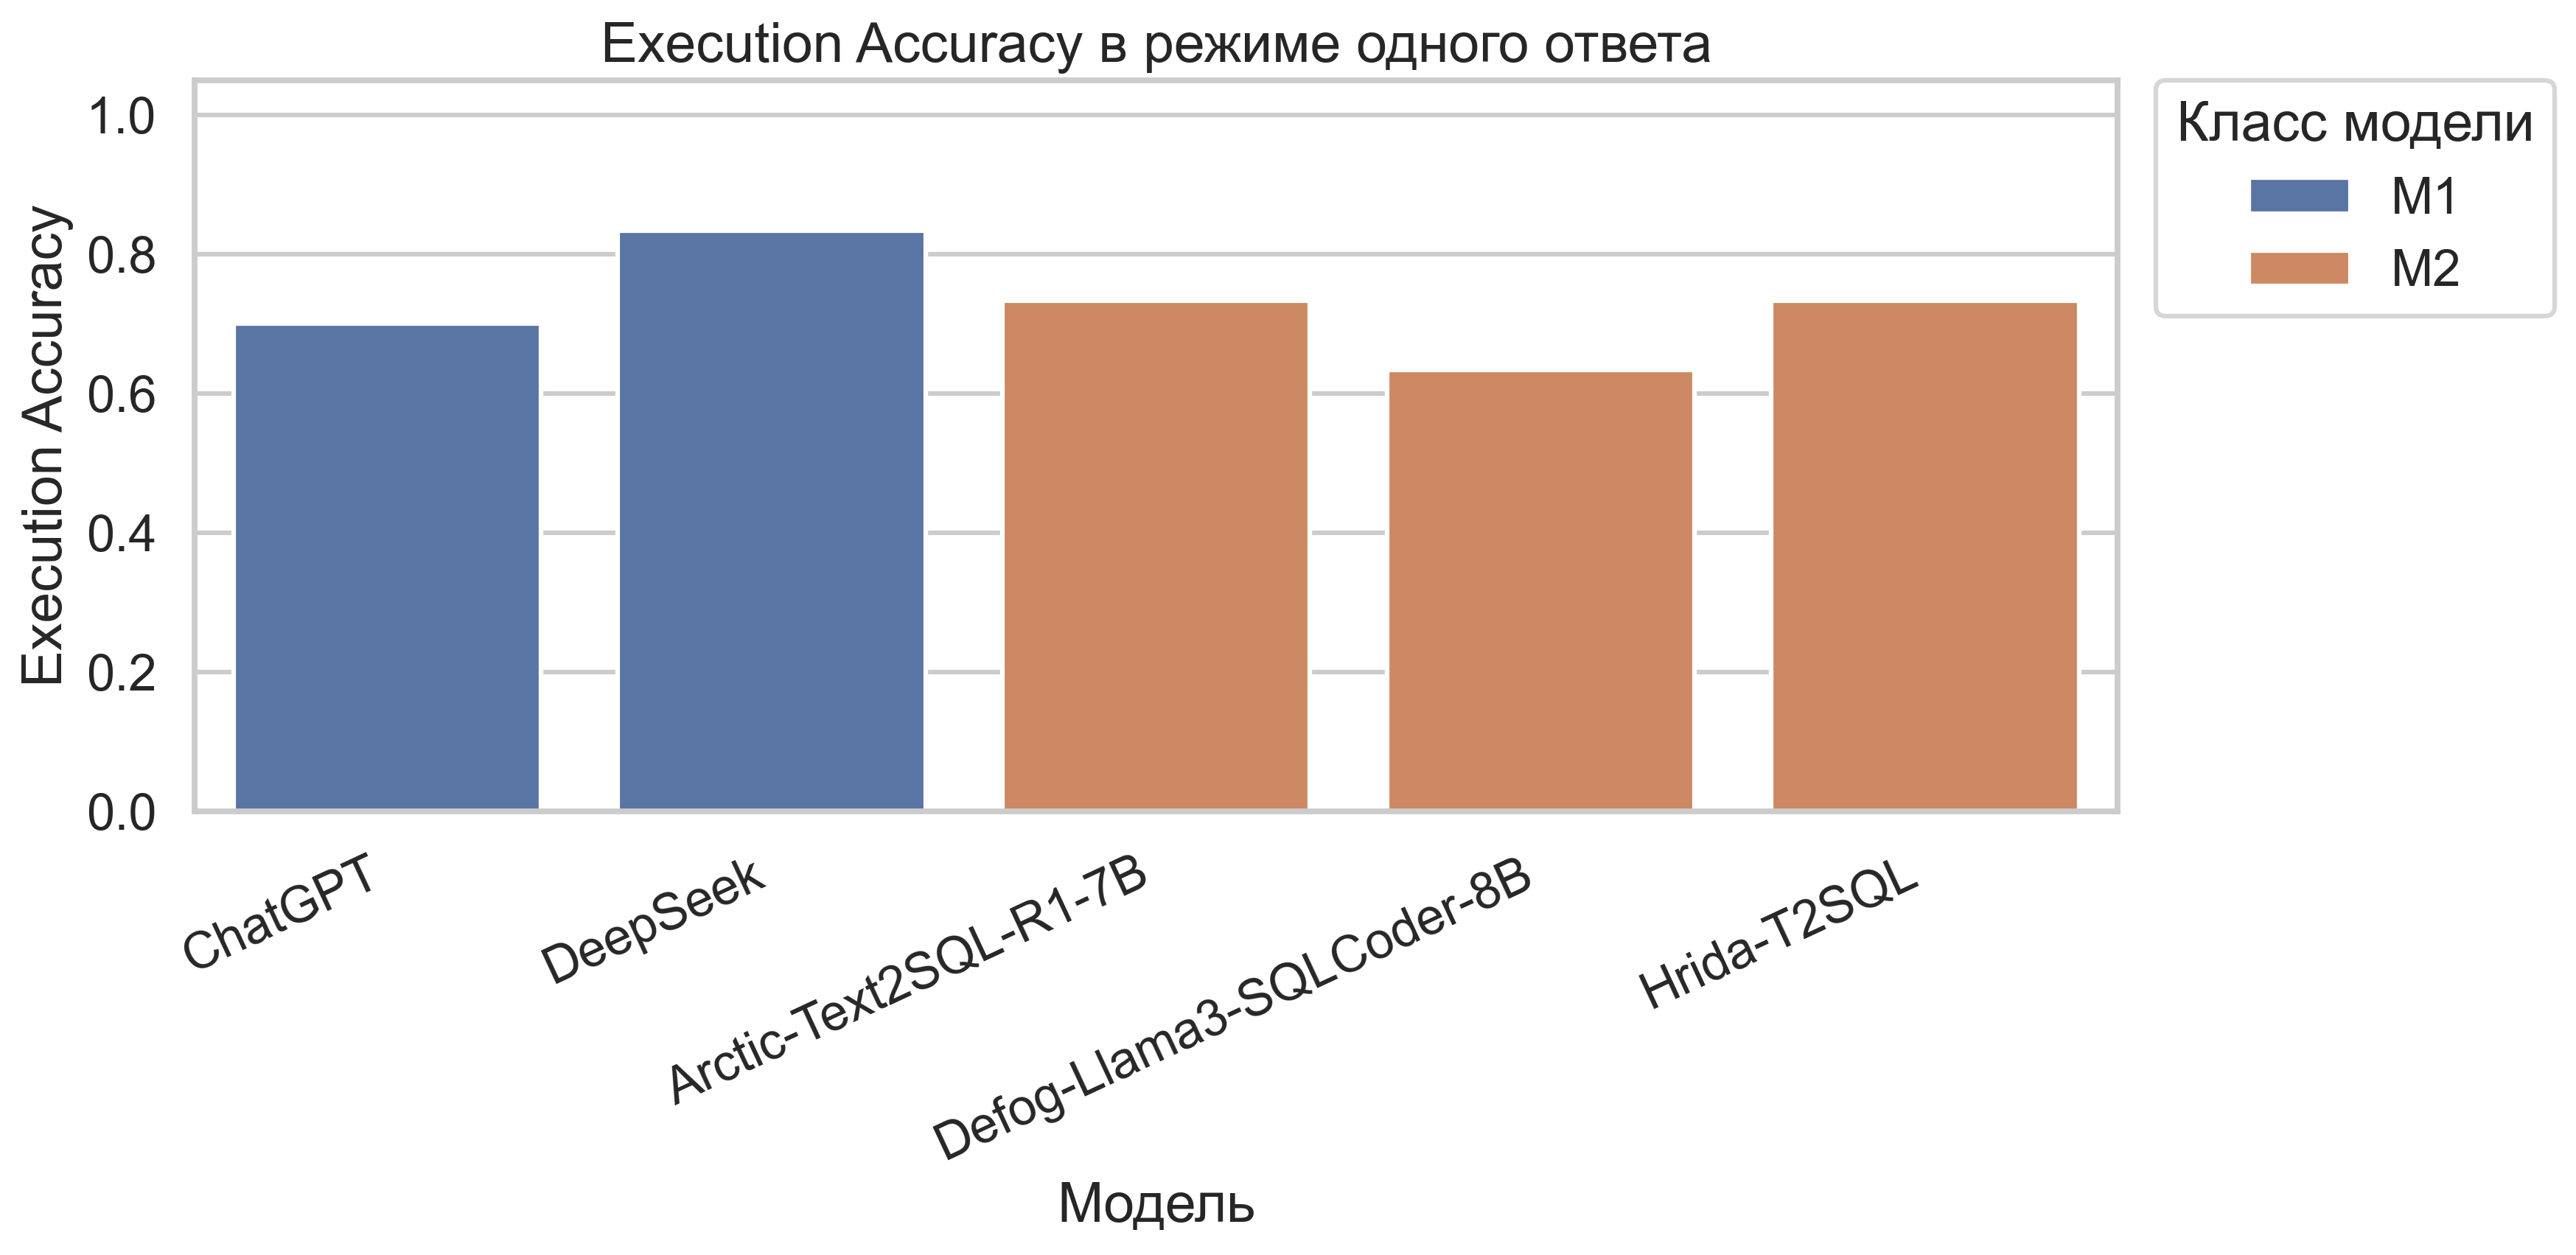

**Рисунок Б.5 — Execution Accuracy моделей SEB по сложности**

> Источник: `results/nl2sql/synthetic_benchmark/figures/synthetic_analysis/seb_ea_by_difficulty_ru.png`

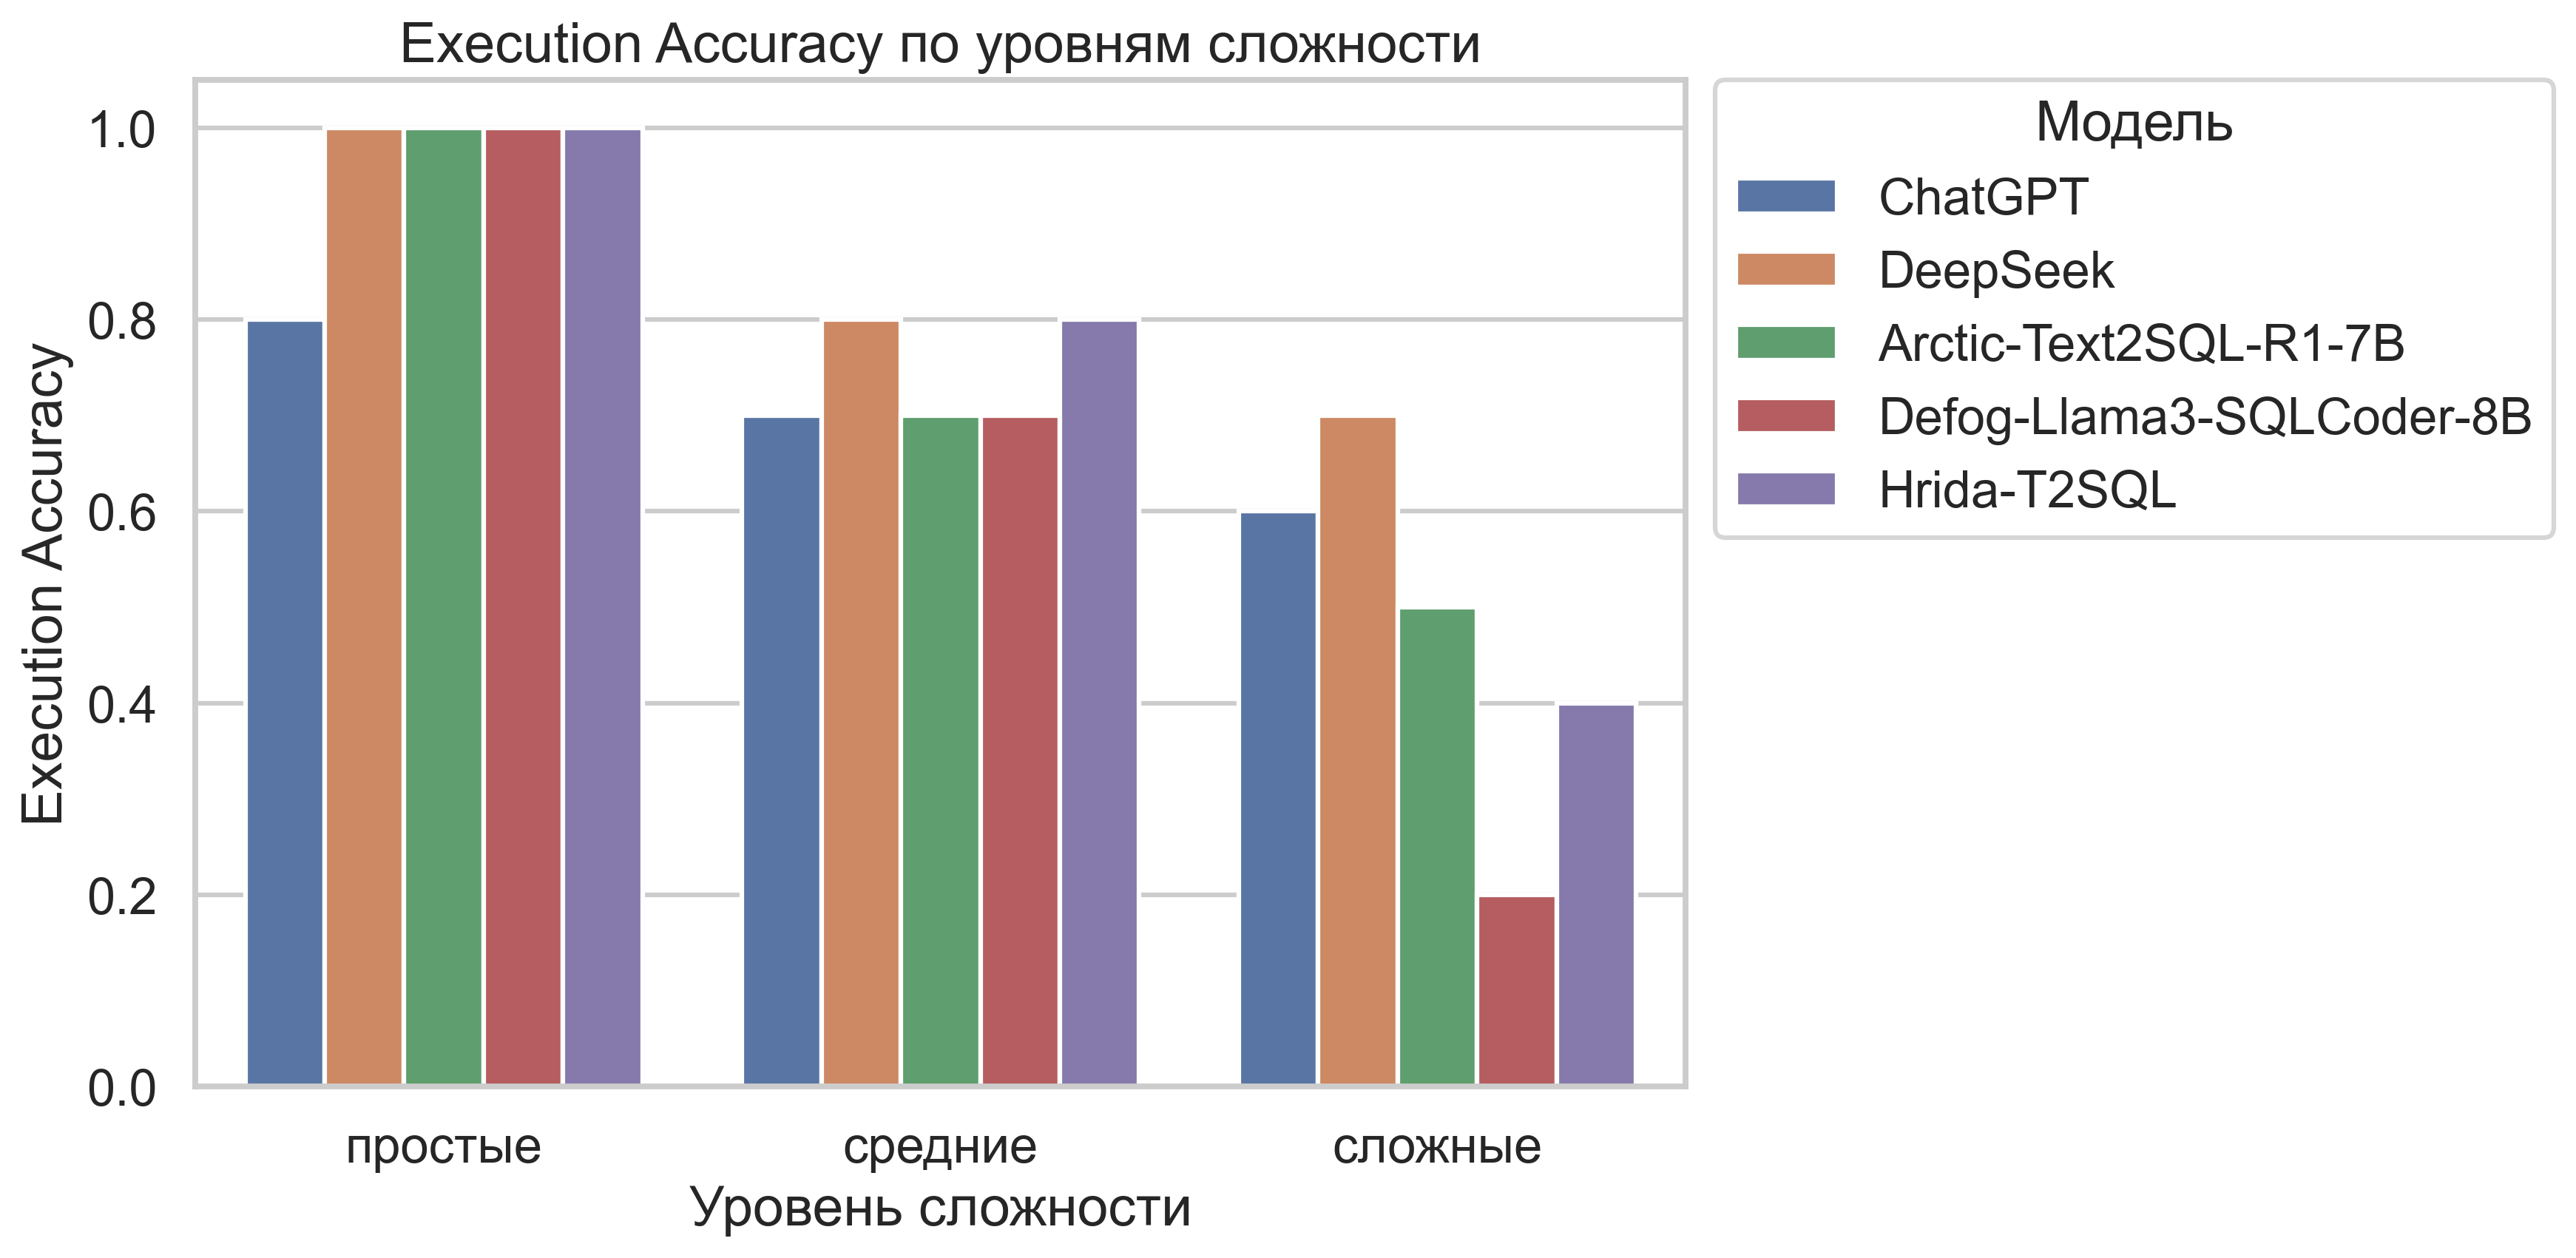

**Рисунок Б.6 — Тепловая карта EA по моделям и сложности SEB**

> Источник: `results/nl2sql/synthetic_benchmark/figures/synthetic_analysis/seb_ea_difficulty_heatmap_ru.png`

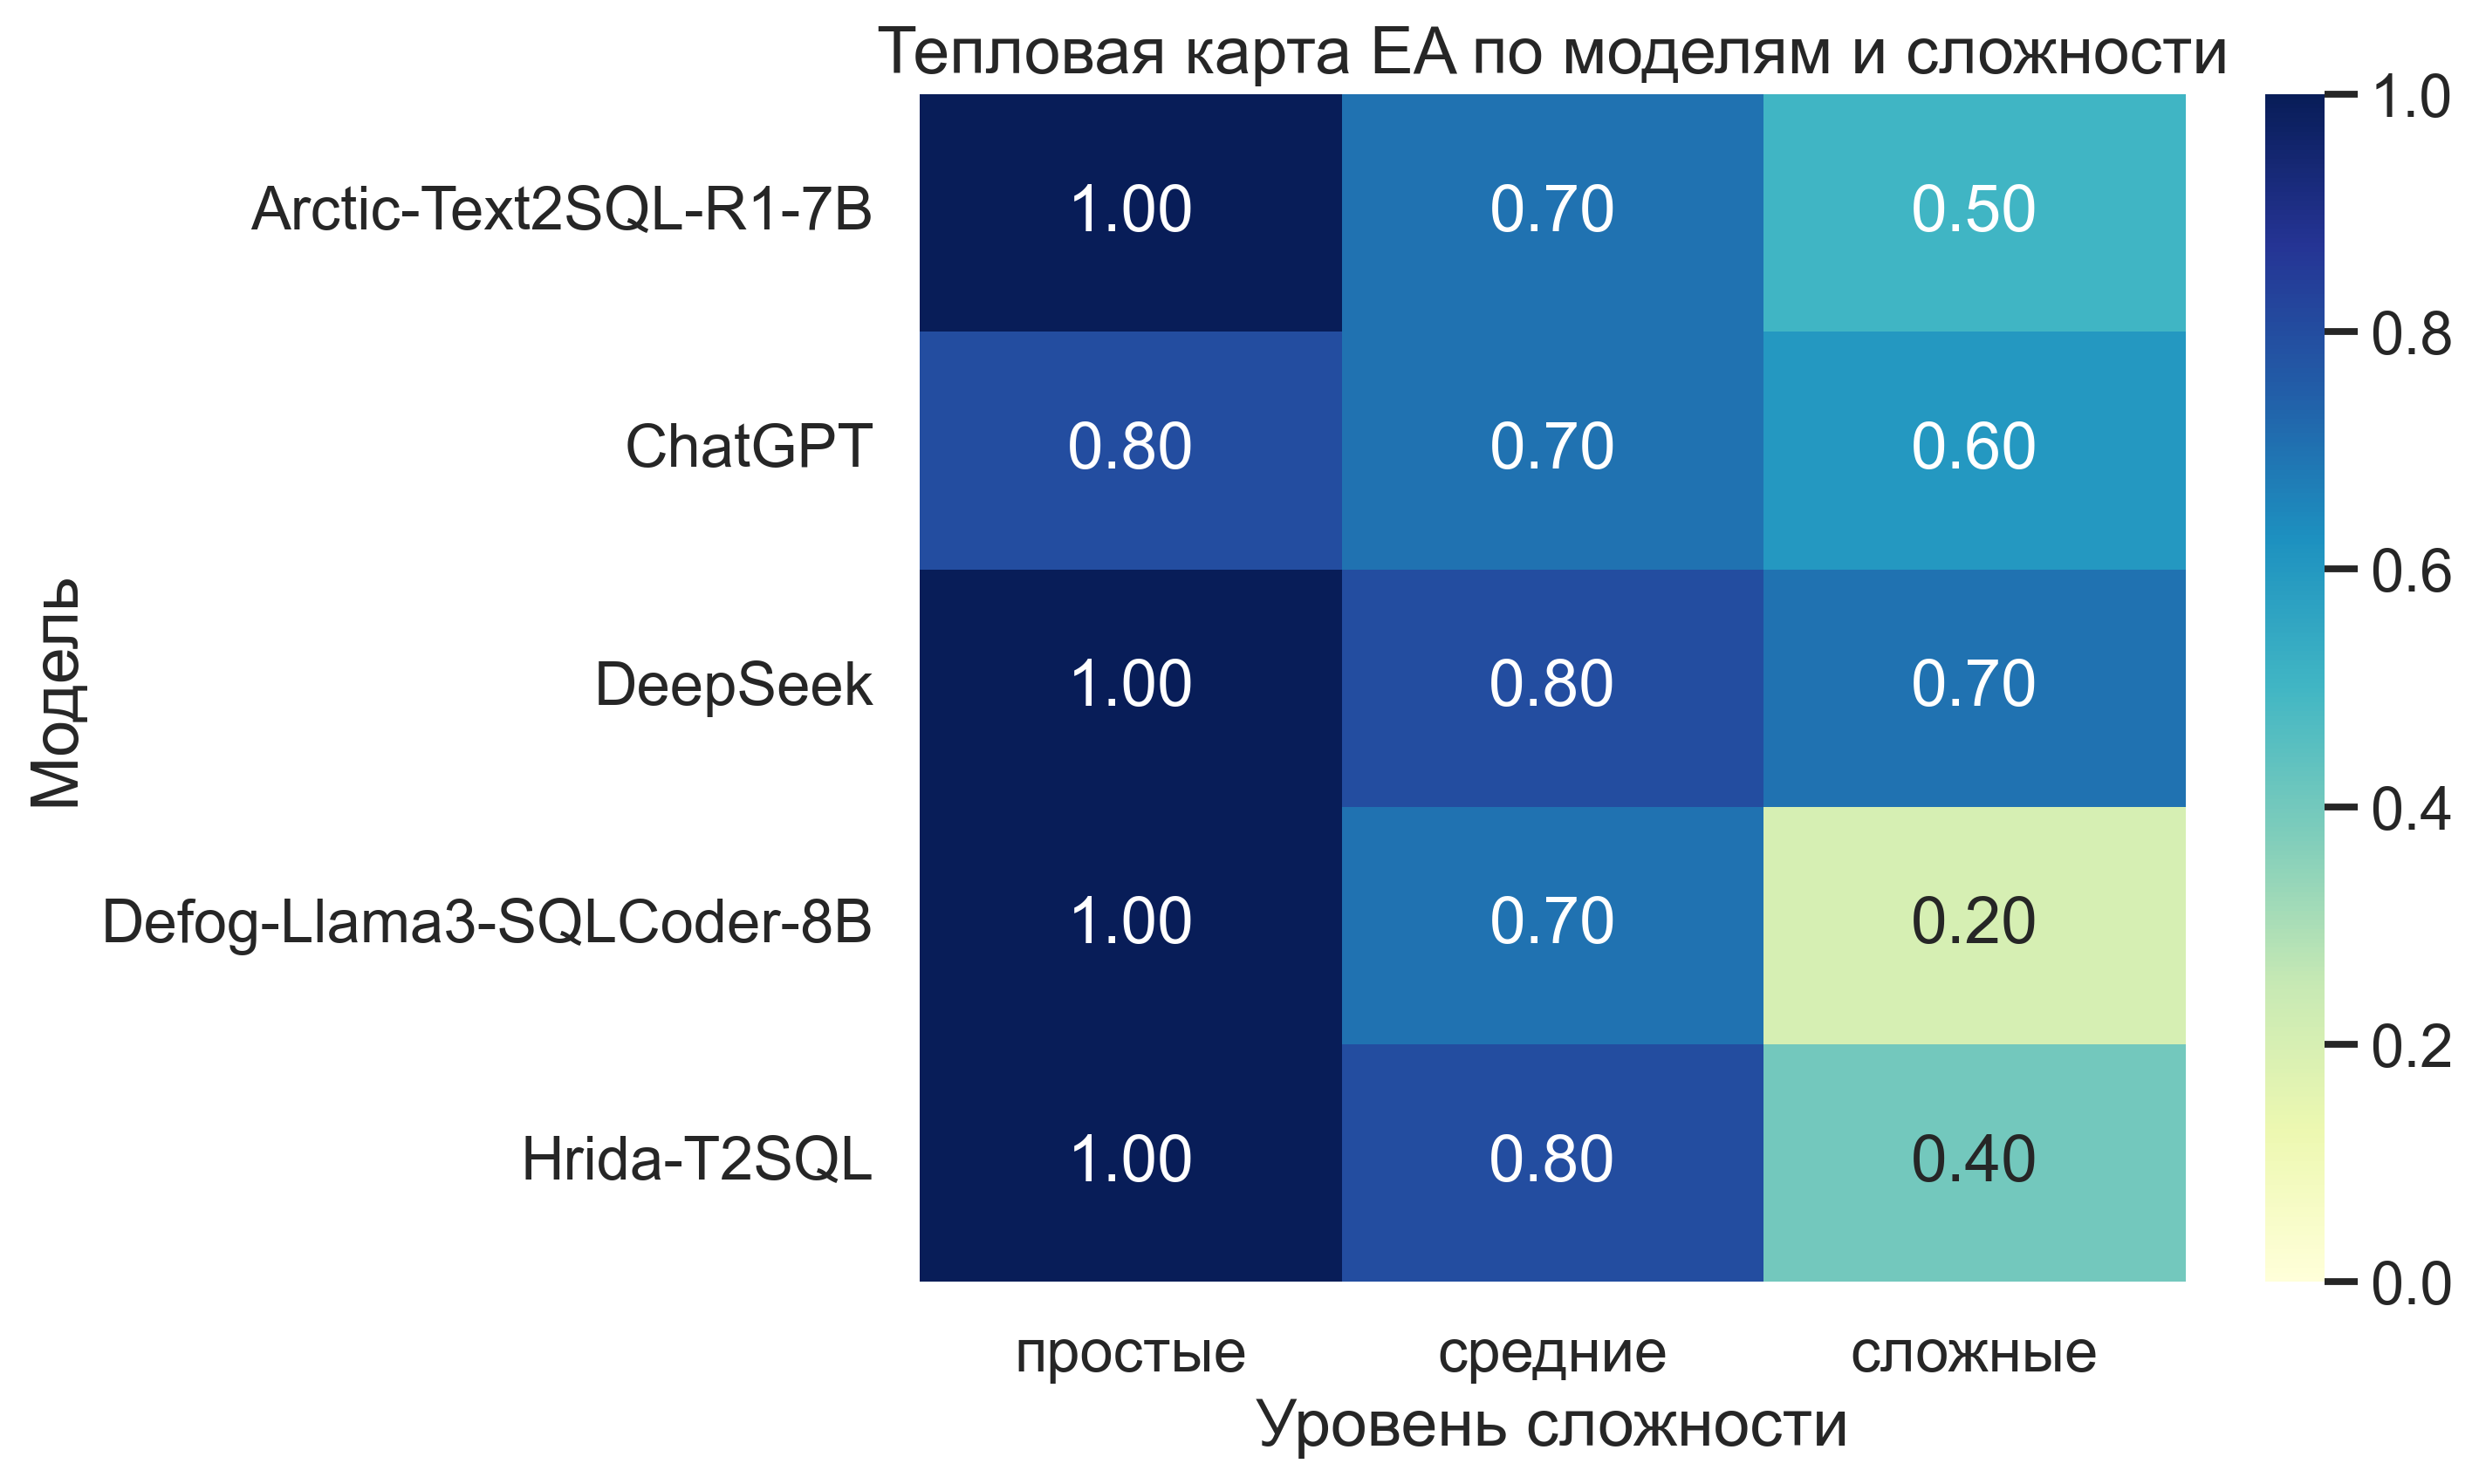

In [3]:
display_table('Таблица Б.1 — Файлы синтетического набора SEB', pd.DataFrame([
    {'Файл': 'dataset_v1.json', 'Назначение': 'Основная схема и ядро SQL-запросов.', 'Путь': rel(SEB_DIR / 'dataset_v1.json')},
    {'Файл': 'edge_cases_v1.json', 'Назначение': 'Дополнительные edge-case SQL-сценарии.', 'Путь': rel(SEB_DIR / 'edge_cases_v1.json')},
    {'Файл': 'seed.sql', 'Назначение': 'SQL-скрипт заполнения SQLite snapshot.', 'Путь': rel(SEB_DIR / 'seed.sql')},
    {'Файл': 'snapshot.sqlite', 'Назначение': 'Готовая исполняемая SQLite-база.', 'Путь': rel(SEB_DIR / 'snapshot.sqlite')},
    {'Файл': 'coverage_summary.json', 'Назначение': 'Сводка покрытия схемы, запросов и особенностей данных.', 'Путь': rel(SEB_DIR / 'coverage_summary.json')},
]))

row_counts_df = pd.DataFrame([{'Таблица': k, 'Количество строк': v} for k, v in coverage.get('row_counts', {}).items()])
display_table('Таблица Б.2 — Размер таблиц SEB', row_counts_df)

schema_rows = []
for item in dataset.get('schema', {}).get('tables', []):
    match = re.match(r'([^\(]+)\((.*)\)', item)
    schema_rows.append({'Таблица': match.group(1) if match else item, 'Описание колонок и ограничений': match.group(2) if match else ''})
display_table('Таблица Б.3 — Реляционная схема SEB', pd.DataFrame(schema_rows))

query_counts = coverage.get('query_counts', {})
display_table('Таблица Б.4 — Состав SQL-запросов SEB', pd.DataFrame([
    {'Группа': 'Основное ядро', 'Количество': query_counts.get('core')},
    {'Группа': 'Edge-case слой', 'Количество': query_counts.get('edge_case')},
    {'Группа': 'Всего', 'Количество': query_counts.get('total')},
]))

core_queries = pd.DataFrame(dataset.get('queries', []))
edge_queries = pd.DataFrame(edge_cases.get('queries', []))
difficulty_df = core_queries['difficulty'].value_counts().rename_axis('Сложность').reset_index(name='Количество') if not core_queries.empty else pd.DataFrame()
display_table('Таблица Б.5 — Распределение core-запросов по сложности', difficulty_df)

display_table('Таблица Б.6 — Edge-case SQL-сценарии', edge_queries.rename(columns={'difficulty': 'Сложность', 'group': 'Группа', 'edge_type': 'Тип edge-case', 'sql': 'SQL'}))

null_ratio_df = pd.DataFrame([
    {'Колонка': k, 'Доля NULL': v}
    for k, v in coverage.get('data_quality_summary', {}).get('null_ratio_by_column', {}).items()
    if v > 0
]).sort_values('Доля NULL', ascending=False)
display_table('Таблица Б.7 — Колонки SEB с ненулевой долей NULL', null_ratio_df, 4)

unusual_values_df = pd.DataFrame([{'Проверка': k, 'Количество': v} for k, v in coverage.get('data_quality_summary', {}).get('unusual_value_checks', {}).items()])
display_table('Таблица Б.8 — Контролируемые нестандартные значения SEB', unusual_values_df)

display_table('Таблица Б.9 — Покрытие пользовательских намерений SEB', pd.DataFrame([{'Пользовательское намерение': k, 'Количество запросов': v} for k, v in coverage.get('intent_distribution', {}).items()]))

table_usage_df = pd.DataFrame([{'Таблица': k, 'Количество использований': v} for k, v in coverage.get('table_usage', {}).items()]).sort_values('Количество использований', ascending=False)
display_table('Таблица Б.10 — Использование таблиц в SQL-запросах SEB', table_usage_df)

for title, fig in [
    ('Рисунок Б.1 — Распределение SQL-запросов SEB по сложности', RESULTS_DIR / 'synthetic_benchmark' / 'figures' / 'synthetic_analysis' / 'seb_dataset_difficulty_ru.png'),
    ('Рисунок Б.2 — Распределение длины вопросов SEB', RESULTS_DIR / 'synthetic_benchmark' / 'figures' / 'synthetic_analysis' / 'seb_question_length_ru.png'),
    ('Рисунок Б.3 — Распределение длины эталонных SQL-запросов SEB', RESULTS_DIR / 'synthetic_benchmark' / 'figures' / 'synthetic_analysis' / 'seb_gold_sql_length_ru.png'),
    ('Рисунок Б.4 — Execution Accuracy моделей на SEB', RESULTS_DIR / 'synthetic_benchmark' / 'figures' / 'synthetic_analysis' / 'seb_ea_overall_ru.png'),
    ('Рисунок Б.5 — Execution Accuracy моделей SEB по сложности', RESULTS_DIR / 'synthetic_benchmark' / 'figures' / 'synthetic_analysis' / 'seb_ea_by_difficulty_ru.png'),
    ('Рисунок Б.6 — Тепловая карта EA по моделям и сложности SEB', RESULTS_DIR / 'synthetic_benchmark' / 'figures' / 'synthetic_analysis' / 'seb_ea_difficulty_heatmap_ru.png'),
]:
    display_png(title, fig)


## Приложение В. Примеры результатов генерации SQL


In [4]:
def pick_example(df: pd.DataFrame, mask: pd.Series, preferred_sample_id: str | None = None) -> pd.Series | None:
    subset = df[mask].copy()
    if subset.empty:
        return None
    if preferred_sample_id and preferred_sample_id in set(subset['sample_id']):
        return subset[subset['sample_id'] == preferred_sample_id].iloc[0]
    return subset.sort_values([c for c in ['benchmark', 'model_display_name', 'sample_id'] if c in subset.columns]).iloc[0]


def render_sql_example(title: str, row: pd.Series | None, result_type: str) -> None:
    display(Markdown(f'**{title}**'))
    if row is None:
        show_note('Подходящий пример не найден в sample_metrics.csv.')
        return
    display(pd.DataFrame([{
        'Тип примера': result_type,
        'Бенчмарк': row.get('benchmark'),
        'Модель': row.get('model_display_name'),
        'sample_id': row.get('sample_id'),
        'Сложность': row.get('difficulty'),
        'Gold success': row.get('gold_success'),
        'Prediction success': row.get('first_pred_success'),
        'Hit': row.get('first_hit'),
        'Ошибка выполнения': row.get('first_pred_error'),
    }]).style.hide(axis='index'))
    md_text = (
        f"**Вопрос:** {row.get('question', '')}\n\n"
        f"**Evidence:** {row.get('evidence', '') if pd.notna(row.get('evidence', '')) else ''}\n\n"
        f"**Эталонный SQL:**\n```sql\n{row.get('gold_sql', '')}\n```\n\n"
        f"**Сгенерированный SQL:**\n```sql\n{row.get('first_pred_sql', '')}\n```"
    )
    display(Markdown(md_text))

if ea_samples.empty:
    show_note('Файл sample_metrics.csv отсутствует или пуст. Примеры генерации SQL не показаны.')
else:
    correct_row = pick_example(ea_samples, ea_samples['first_hit'].fillna(False).astype(bool), 'bird_0')
    exec_error_row = pick_example(ea_samples, (~ea_samples['first_pred_success'].fillna(False).astype(bool)) & ea_samples['first_pred_error'].notna())
    wrong_executable_row = pick_example(ea_samples, ea_samples['first_pred_success'].fillna(False).astype(bool) & (~ea_samples['first_hit'].fillna(False).astype(bool)))
    render_sql_example('В.1 — Корректная генерация', correct_row, 'Корректный результат')
    render_sql_example('В.2 — Ошибка выполнения SQL', exec_error_row, 'Ошибка выполнения')
    render_sql_example('В.3 — Исполнимый SQL с некорректным результатом', wrong_executable_row, 'Исполнимо, но неверный результат')


**В.1 — Корректная генерация**

Тип примера,Бенчмарк,Модель,sample_id,Сложность,Gold success,Prediction success,Hit,Ошибка выполнения
Корректный результат,bird,Arctic-Text2SQL-R1-7B,bird_0,simple,True,True,True,nan


**Вопрос:** What is the highest eligible free rate for K-12 students in the schools in Alameda County?

**Evidence:** Eligible free rate for K-12 = `Free Meal Count (K-12)` / `Enrollment (K-12)`

**Эталонный SQL:**
```sql
SELECT `Free Meal Count (K-12)` / `Enrollment (K-12)` FROM frpm WHERE `County Name` = 'Alameda' ORDER BY (CAST(`Free Meal Count (K-12)` AS REAL) / `Enrollment (K-12)`) DESC LIMIT 1
```

**Сгенерированный SQL:**
```sql
SELECT MAX(`Percent (%) Eligible Free (K-12)`) AS HighestEligibleFreeRate
FROM frpm
WHERE `County Name` = 'Alameda'
```

**В.2 — Ошибка выполнения SQL**

Тип примера,Бенчмарк,Модель,sample_id,Сложность,Gold success,Prediction success,Hit,Ошибка выполнения
Ошибка выполнения,bird,Arctic-Text2SQL-R1-7B,bird_1163,simple,True,False,False,no such column: First_Date


**Вопрос:** What was the age of the youngest patient when they initially arrived at the hospital?

**Evidence:** age refers to SUBTRACT(YEAR(`First Date`),YEAR(Birthday))

**Эталонный SQL:**
```sql
SELECT MIN(STRFTIME('%Y', `First Date`) - STRFTIME('%Y', Birthday)) FROM Patient
```

**Сгенерированный SQL:**
```sql
SELECT 
    (strftime('%Y', First_Date) - strftime('%Y', Birthday)) AS Age_at_Arrival
FROM Patient
ORDER BY Age_at_Arrival ASC
LIMIT 1
```

**В.3 — Исполнимый SQL с некорректным результатом**

Тип примера,Бенчмарк,Модель,sample_id,Сложность,Gold success,Prediction success,Hit,Ошибка выполнения
"Исполнимо, но неверный результат",bird,Arctic-Text2SQL-R1-7B,bird_1,moderate,True,True,False,nan


**Вопрос:** Please list the lowest three eligible free rates for students aged 5-17 in continuation schools.

**Evidence:** Eligible free rates for students aged 5-17 = `Free Meal Count (Ages 5-17)` / `Enrollment (Ages 5-17)`

**Эталонный SQL:**
```sql
SELECT `Free Meal Count (Ages 5-17)` / `Enrollment (Ages 5-17)` FROM frpm WHERE `Educational Option Type` = 'Continuation School' AND `Free Meal Count (Ages 5-17)` / `Enrollment (Ages 5-17)` IS NOT NULL ORDER BY `Free Meal Count (Ages 5-17)` / `Enrollment (Ages 5-17)` ASC LIMIT 3
```

**Сгенерированный SQL:**
```sql
SELECT 
    `County Name`, 
    `District Name`, 
    `School Name`, 
    (`Free Meal Count (Ages 5-17)` / `Enrollment (Ages 5-17)`) * 100 AS EligibleFreeRate
FROM frpm
WHERE `School Type` = 'Continuation School'
ORDER BY EligibleFreeRate ASC
LIMIT 3
```

## Приложение Г. Дополнительные материалы по режиму Pass@K

В приложении `Pass@K` приводится отдельно от графиков `EA` в режиме одного ответа. Диаграммы показывают зависимость качества от числа попыток генерации и эффект нескольких кандидатов на Synthetic E-commerce Benchmark. Старые сгруппированные столбчатые диаграммы, где `EA`, `pass@1`, `pass@3` и `pass@5` отображались как равноправные категории, больше не используются.


**Таблица Г.1 — Полные результаты Pass@K по актуальным SQL-моделям**

Модель,Бенчмарк,N,EA,Pass@1,Pass@3,Pass@5,"Tinf, мс",Токены,"Стоимость, $"
ChatGPT 5.2,bird,1534,0.286800,0.287500,0.352400,0.373500,2186.995100,1020.665300,0.001900
DeepSeek V3.2,bird,1534,0.317500,0.320100,0.348200,0.361100,2950.705600,1051.619200,0.000300
Arctic-Text2SQL-R1-7B,bird,1534,0.213200,0.211600,0.225300,0.234700,1937.288300,1071.072200,0.000000
Defog-Llama3-SQLCoder-8B q4_0,bird,1534,0.125800,0.127900,0.145600,0.157100,1625.685300,1010.058300,0.000000
Hrida-T2SQL q8_0,bird,1534,0.037800,0.034200,0.037500,0.040400,1344.523100,1403.713800,0.000000
ChatGPT 5.2,spider,1034,0.741800,0.742400,0.763700,0.771800,1988.885600,479.015700,0.000900
DeepSeek V3.2,spider,1034,0.737900,0.739500,0.761900,0.769800,2284.473900,514.880300,0.000100
Arctic-Text2SQL-R1-7B,spider,1034,0.552200,0.553800,0.575000,0.589000,1494.257000,554.780100,0.000000
Defog-Llama3-SQLCoder-8B q4_0,spider,1034,0.432300,0.430000,0.468300,0.494200,1235.264300,483.047600,0.000000
Hrida-T2SQL q8_0,spider,1034,0.341400,0.346800,0.365600,0.377200,704.045000,720.338300,0.000000


> Количество строк в Pass@K-таблице: 10. Ожидается 10 строк: 5 моделей x 2 бенчмарка.

**Рисунок Г.1 — Число задач в наборах данных Pass@K**

> Источник: `results/nl2sql/figures/pass_k/dataset_samples_ru.png`

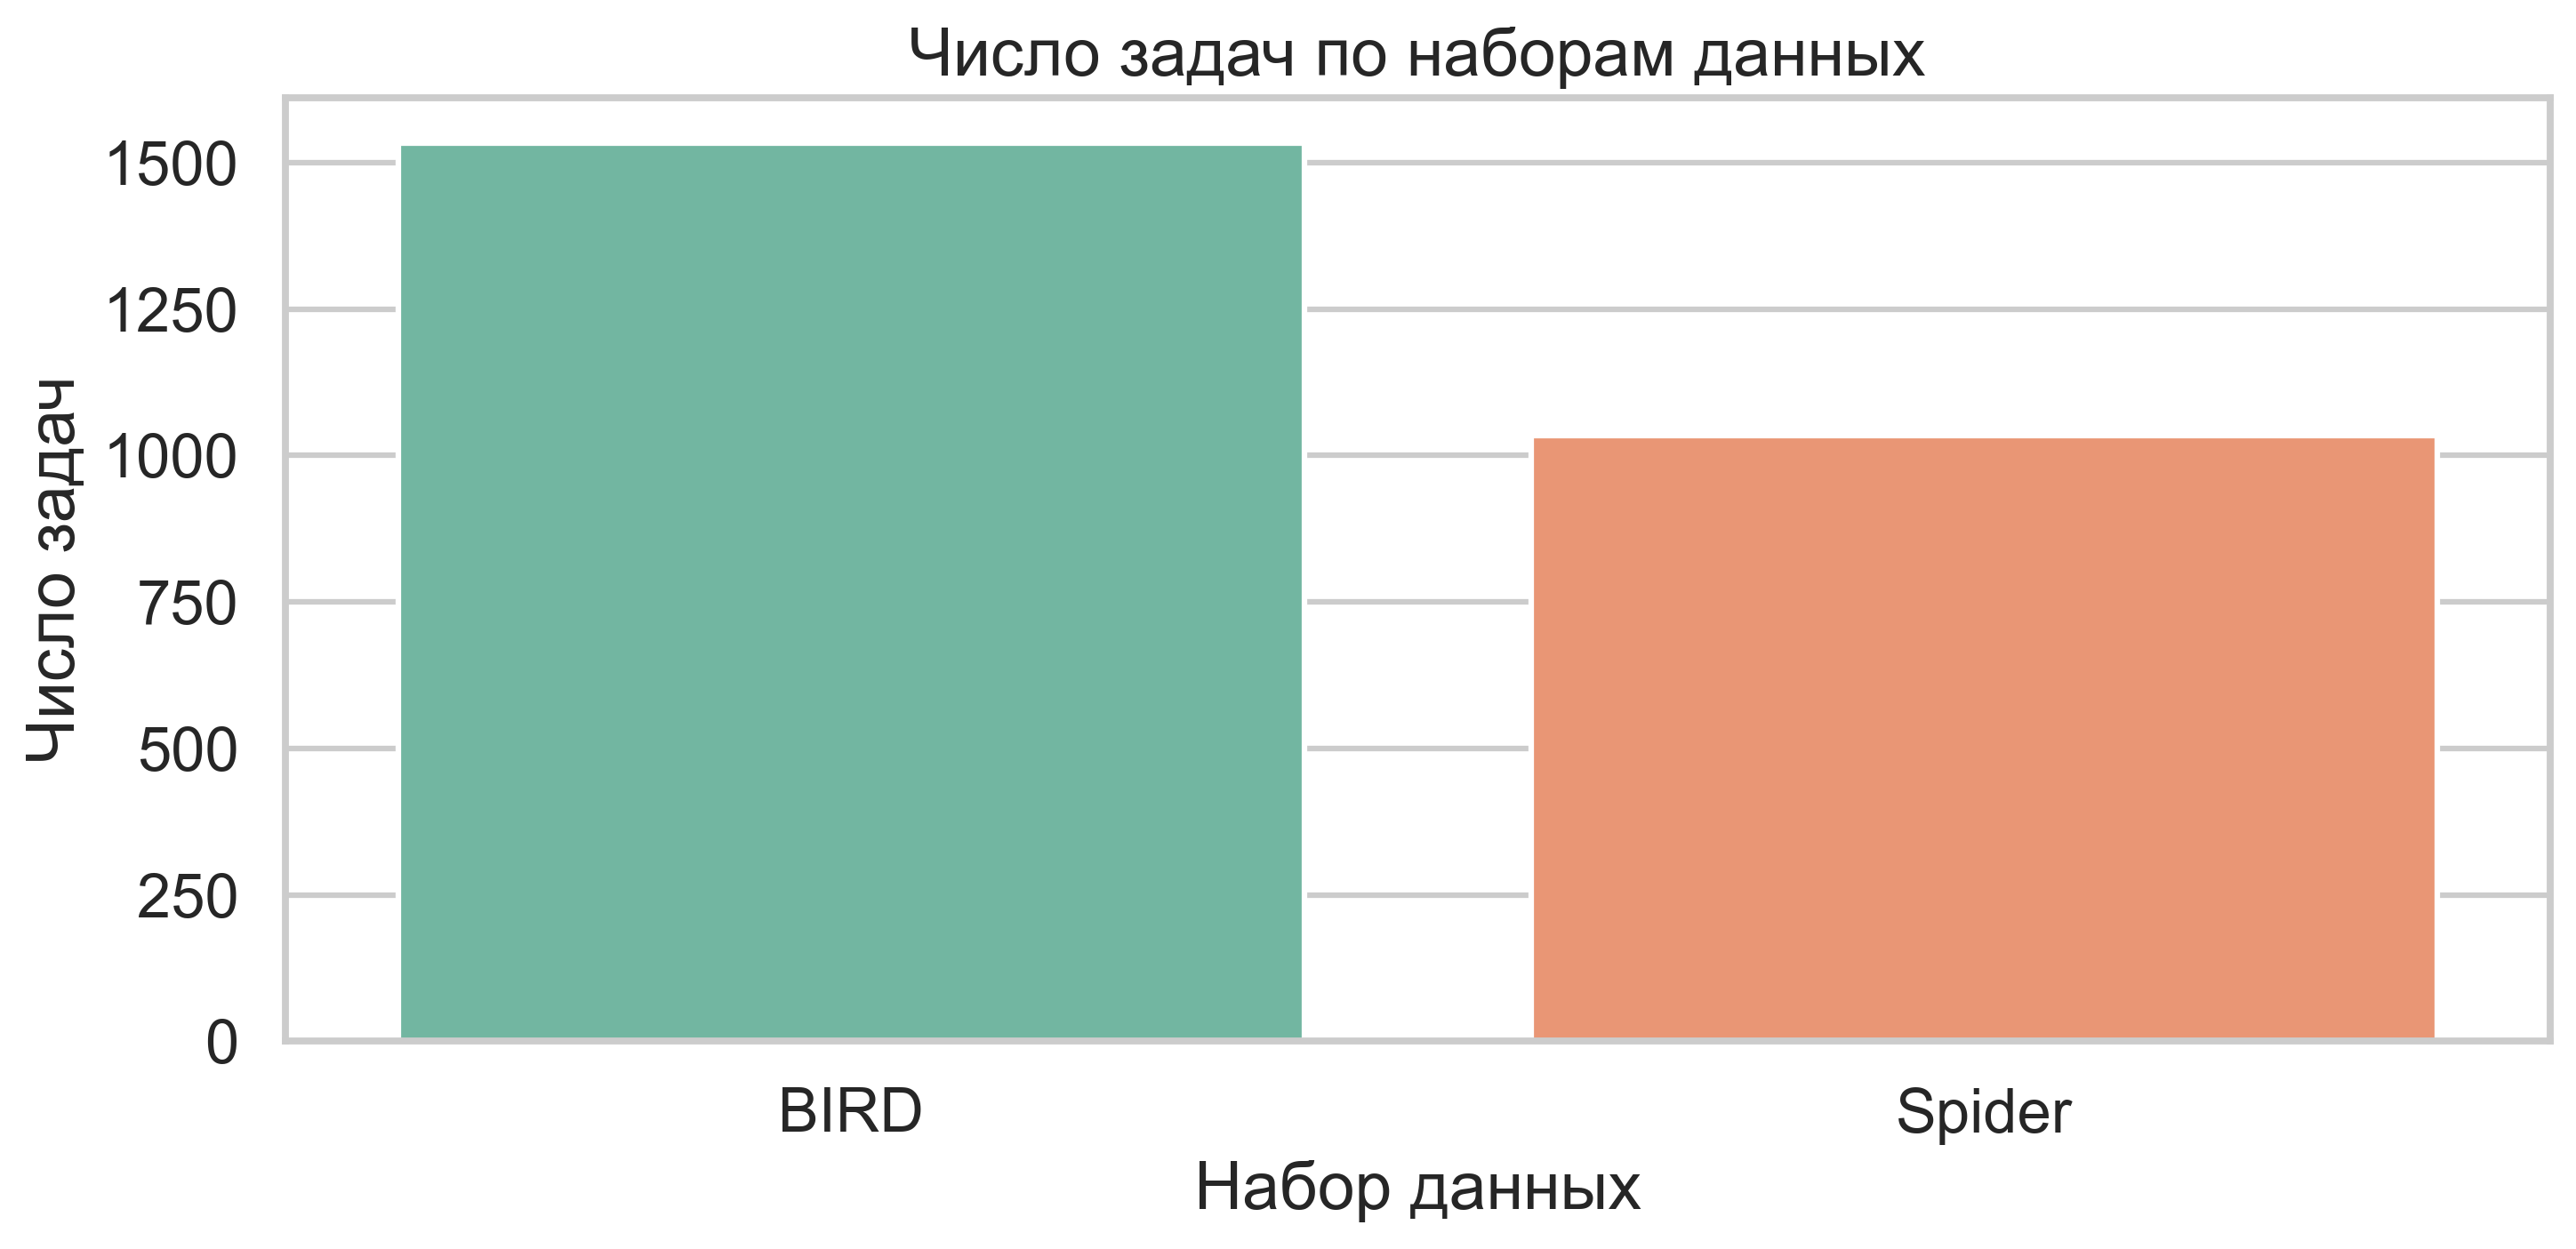

**Рисунок Г.2 — Распределение длины вопросов Pass@K**

> Источник: `results/nl2sql/figures/pass_k/dataset_question_length_ru.png`

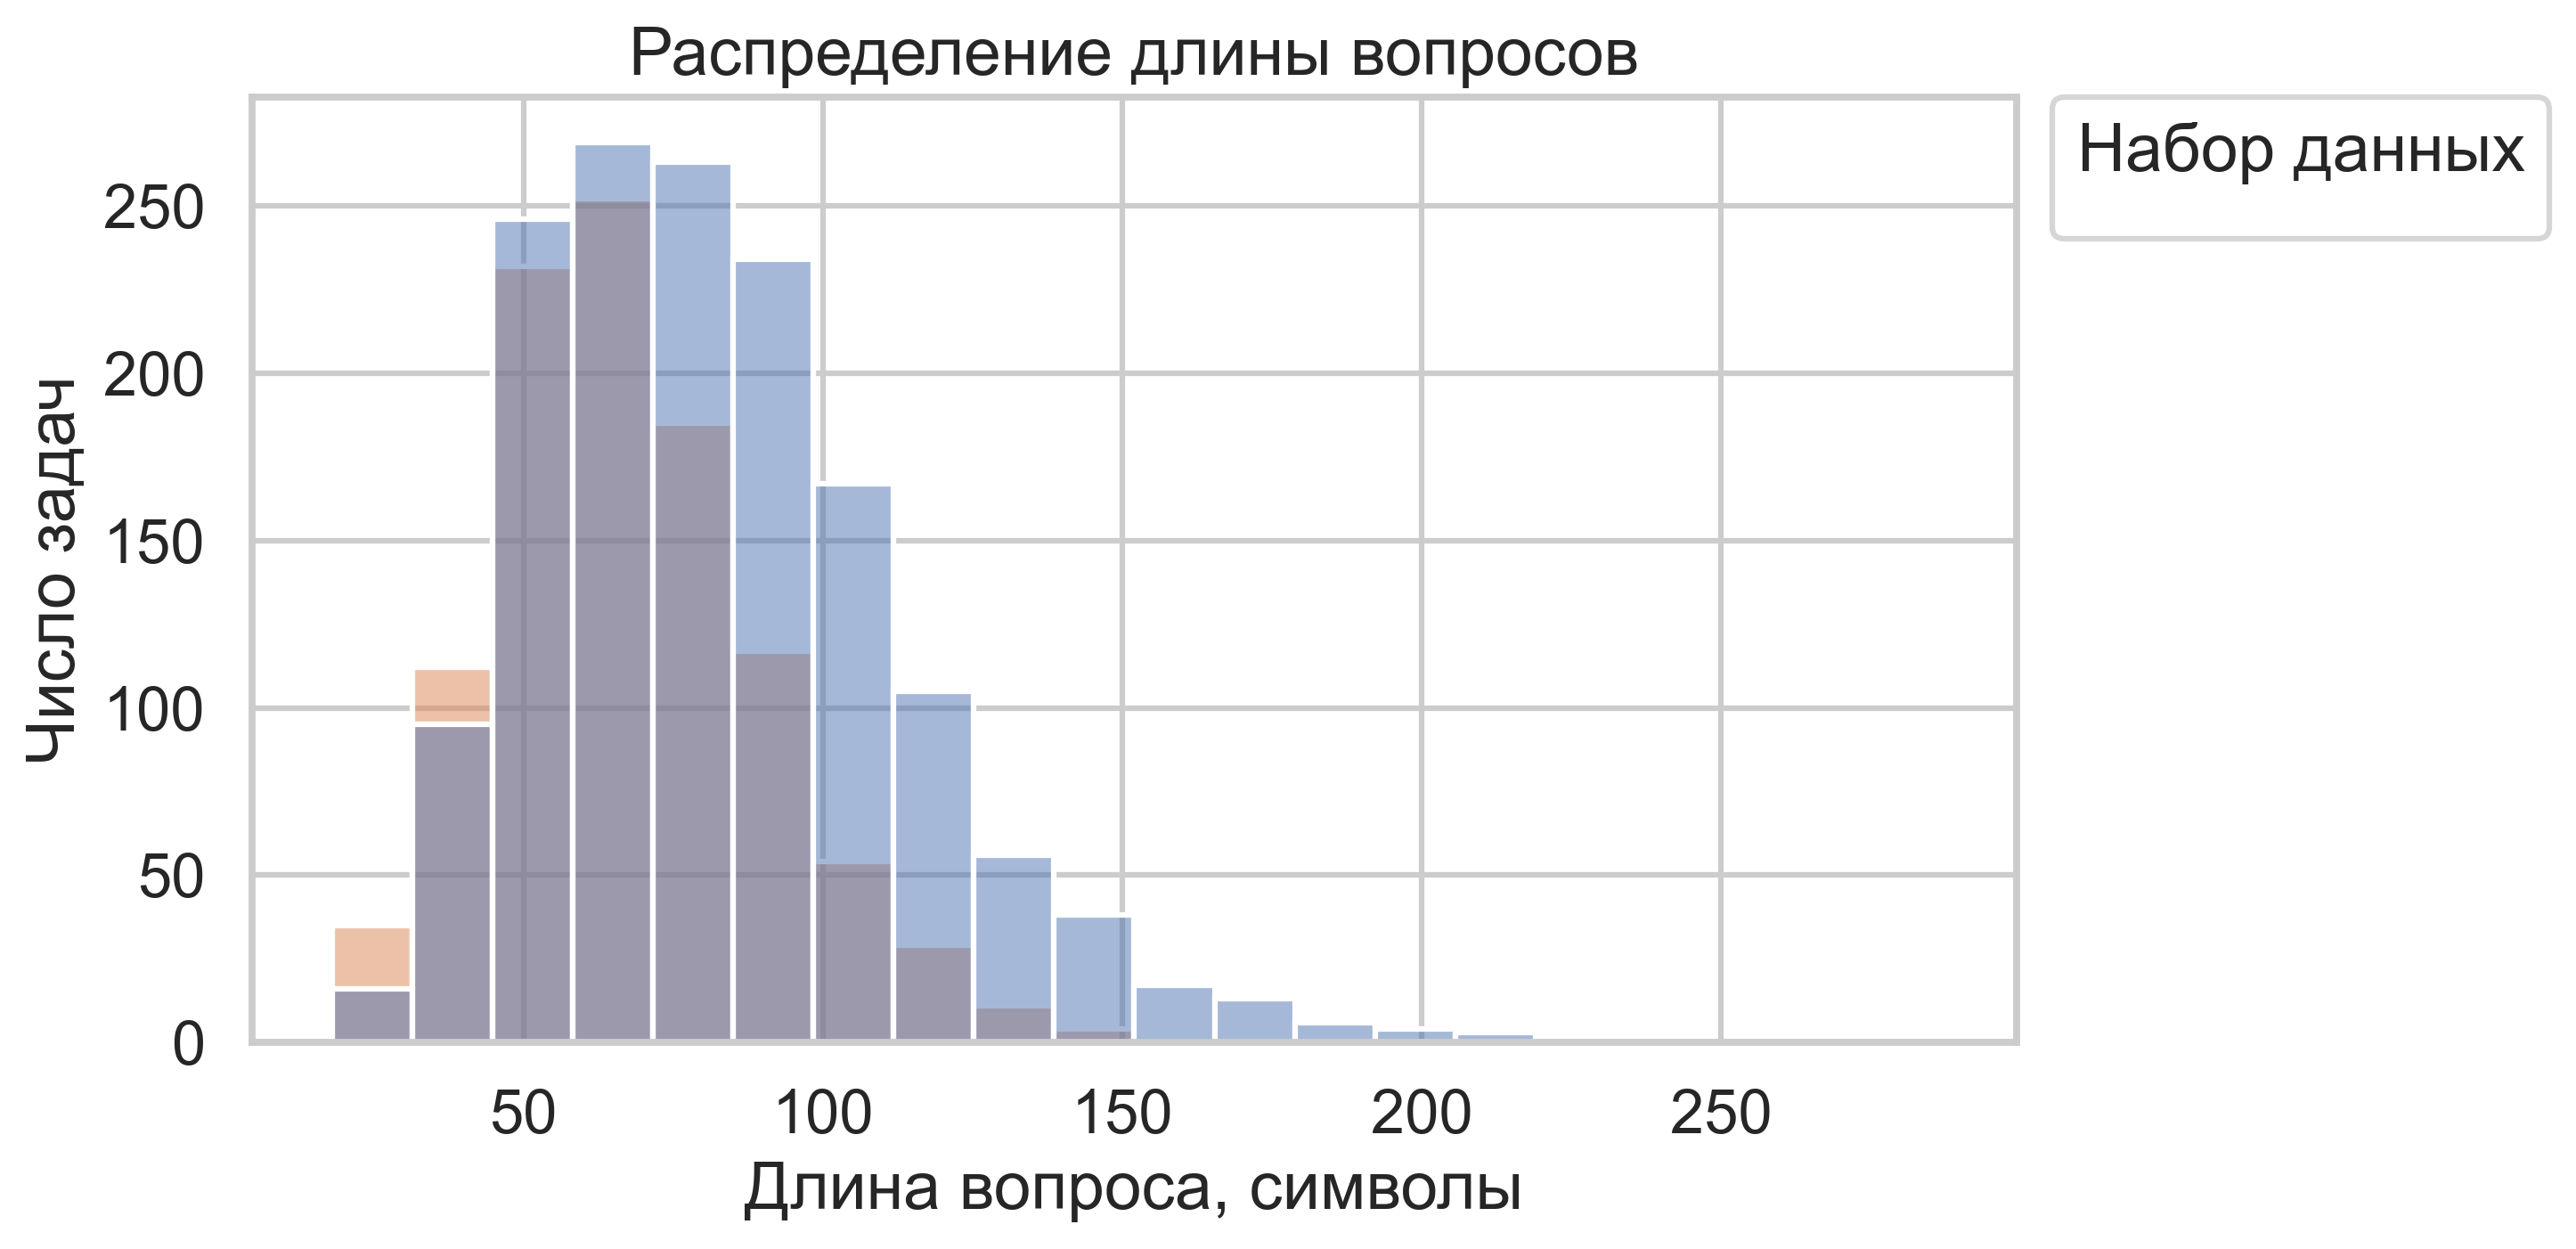

**Рисунок Г.3 — Pass@K моделей на Spider и BIRD**

> Источник: `results/nl2sql/figures/pass_k/passk_by_model_ru.png`

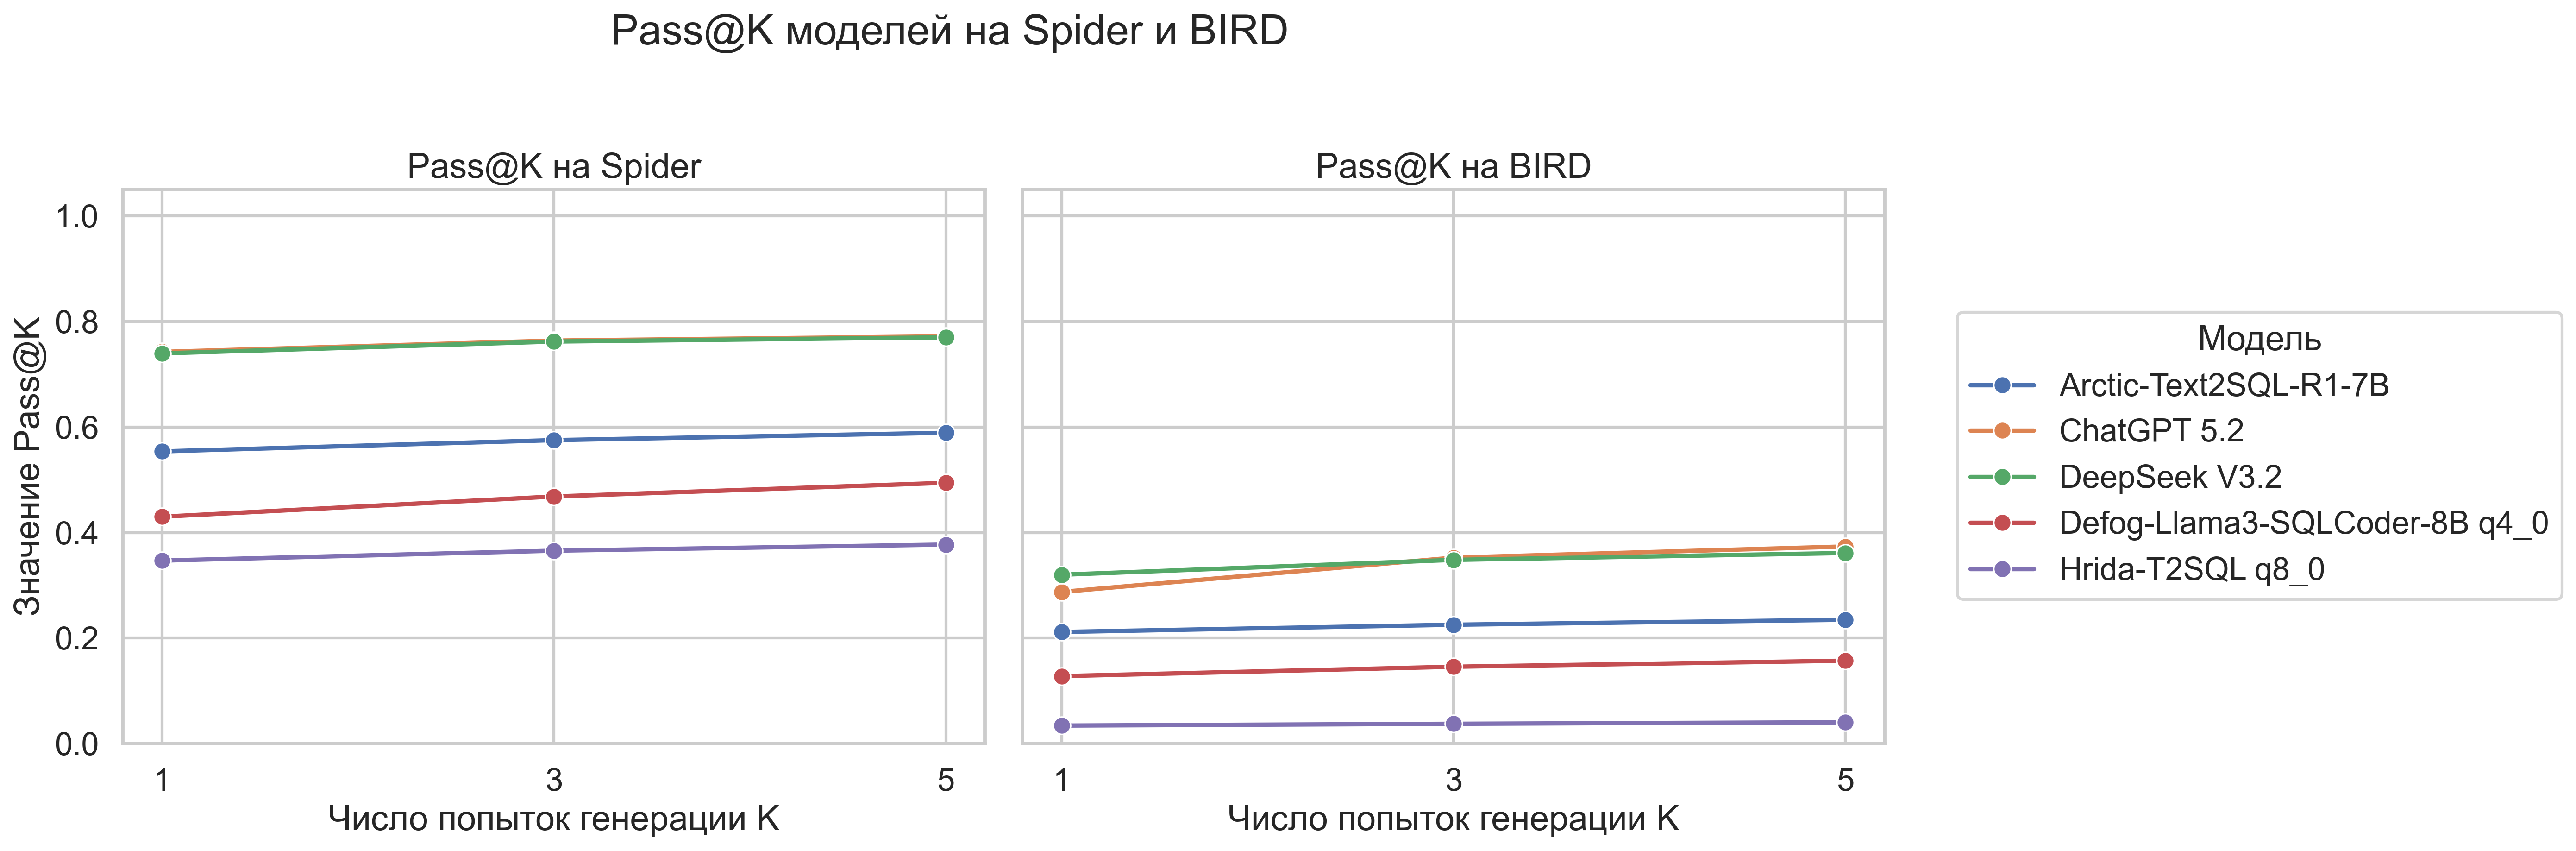

**Рисунок Г.4 — Время инференса в режиме Pass@K**

> Источник: `results/nl2sql/figures/pass_k/eff_latency_ru.png`

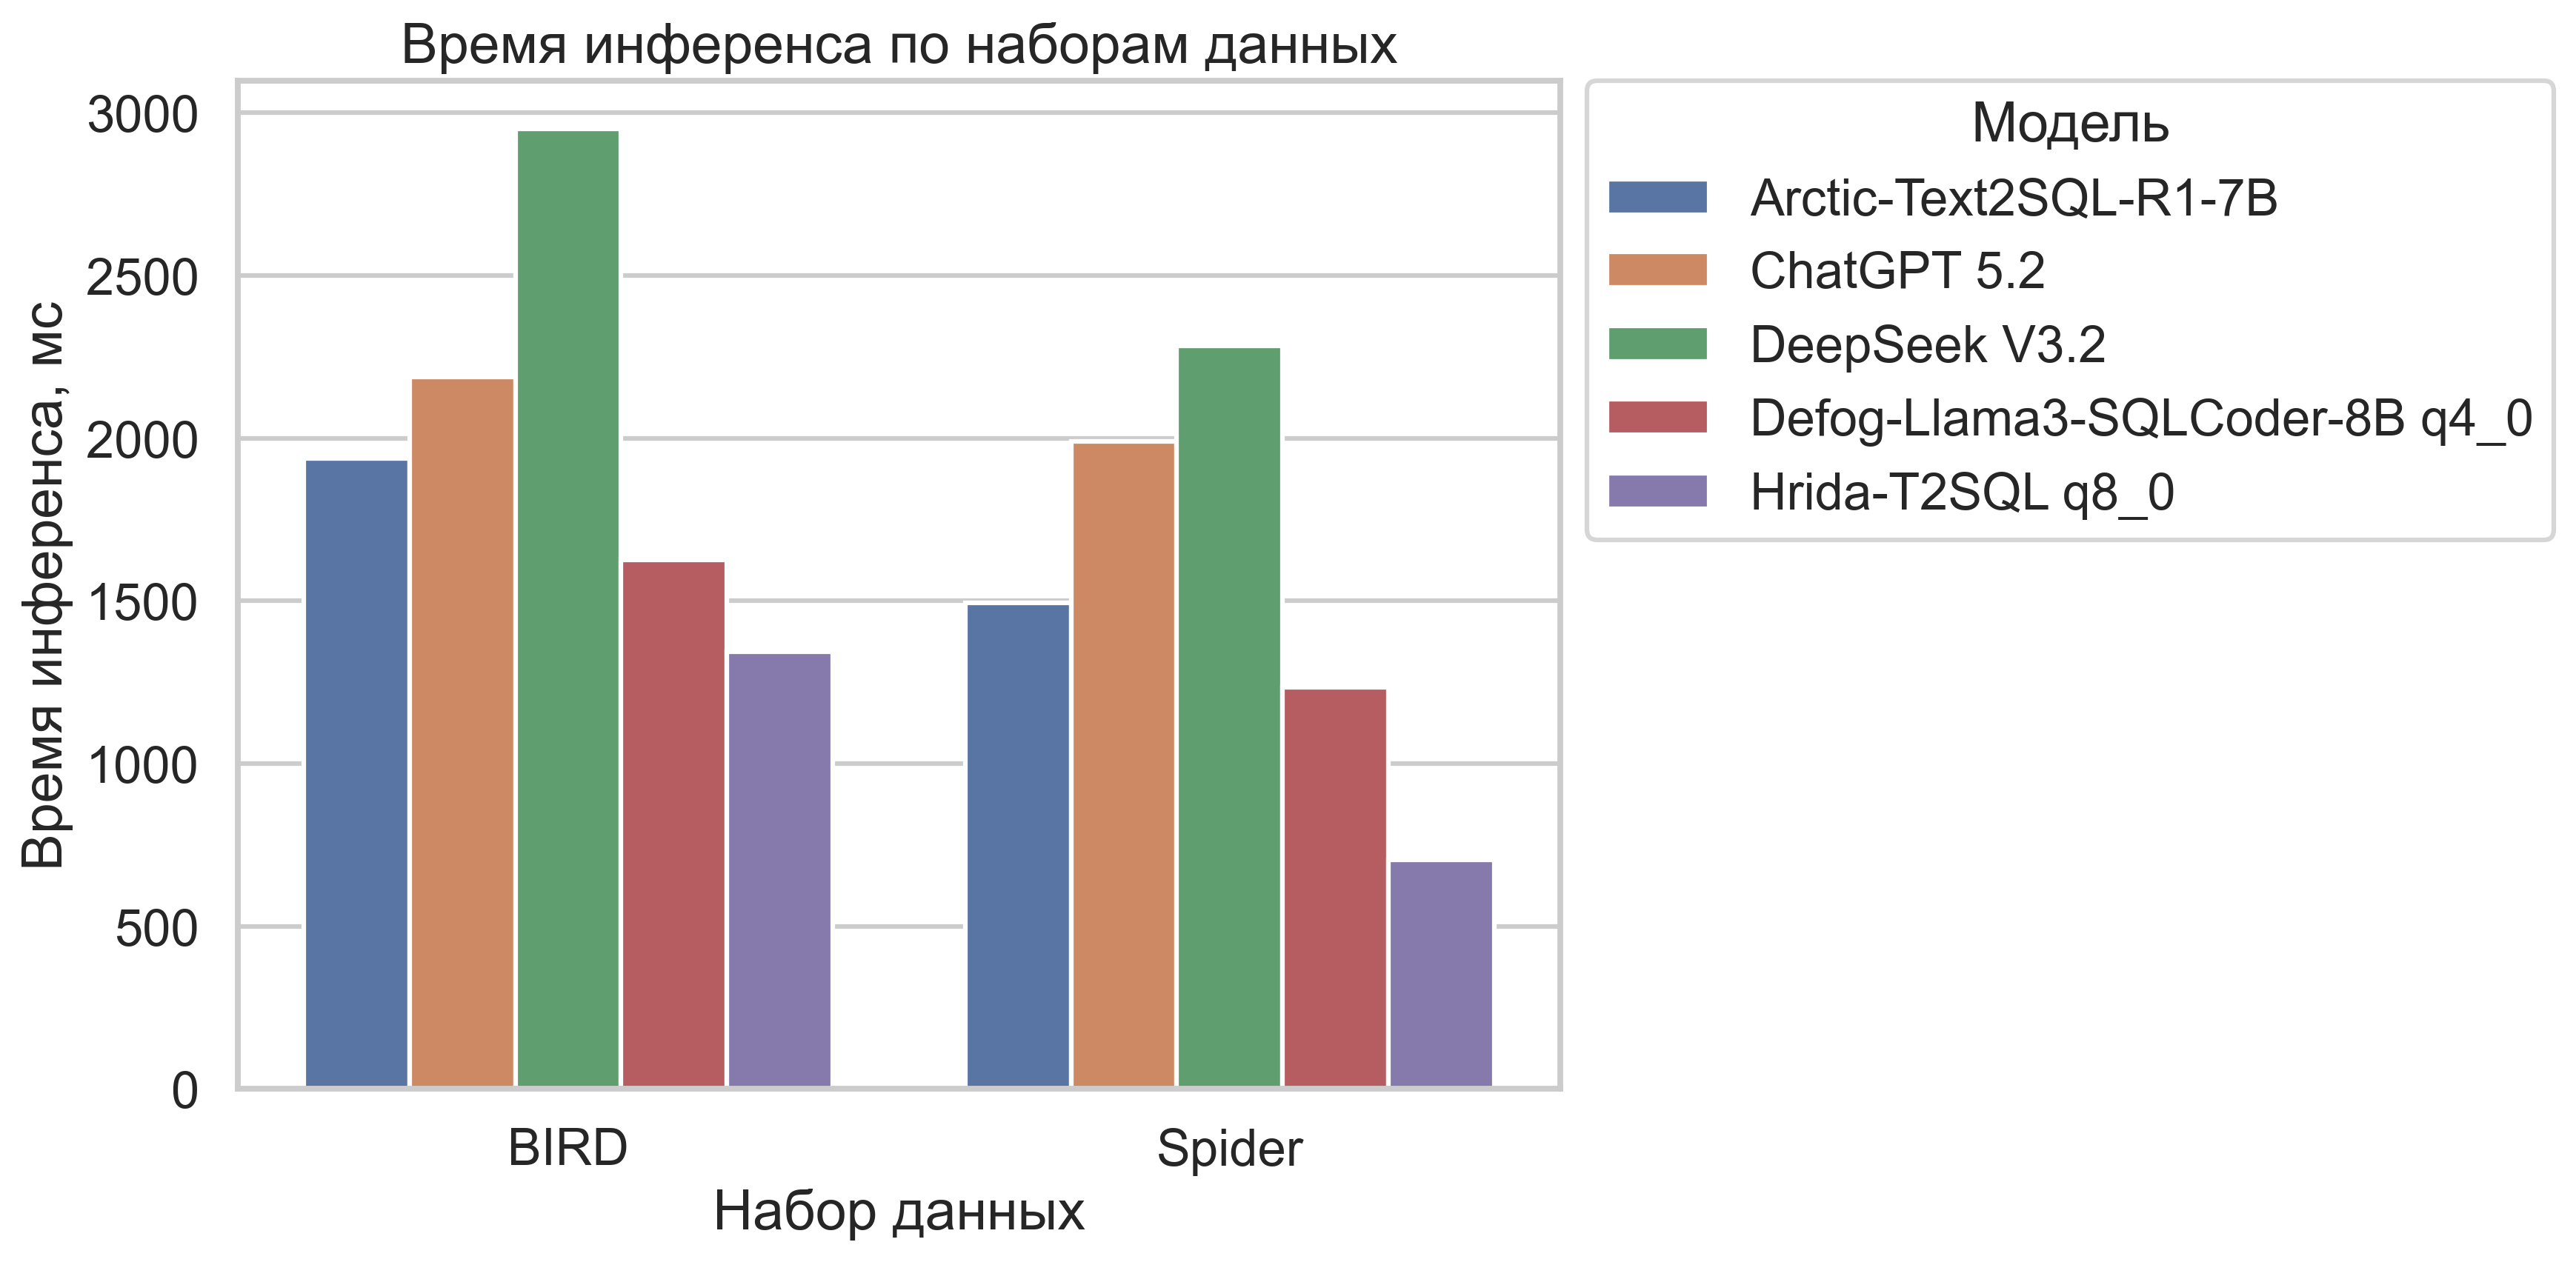

**Рисунок Г.5 — Стоимость инференса в режиме Pass@K**

> Источник: `results/nl2sql/figures/pass_k/eff_cost_ru.png`

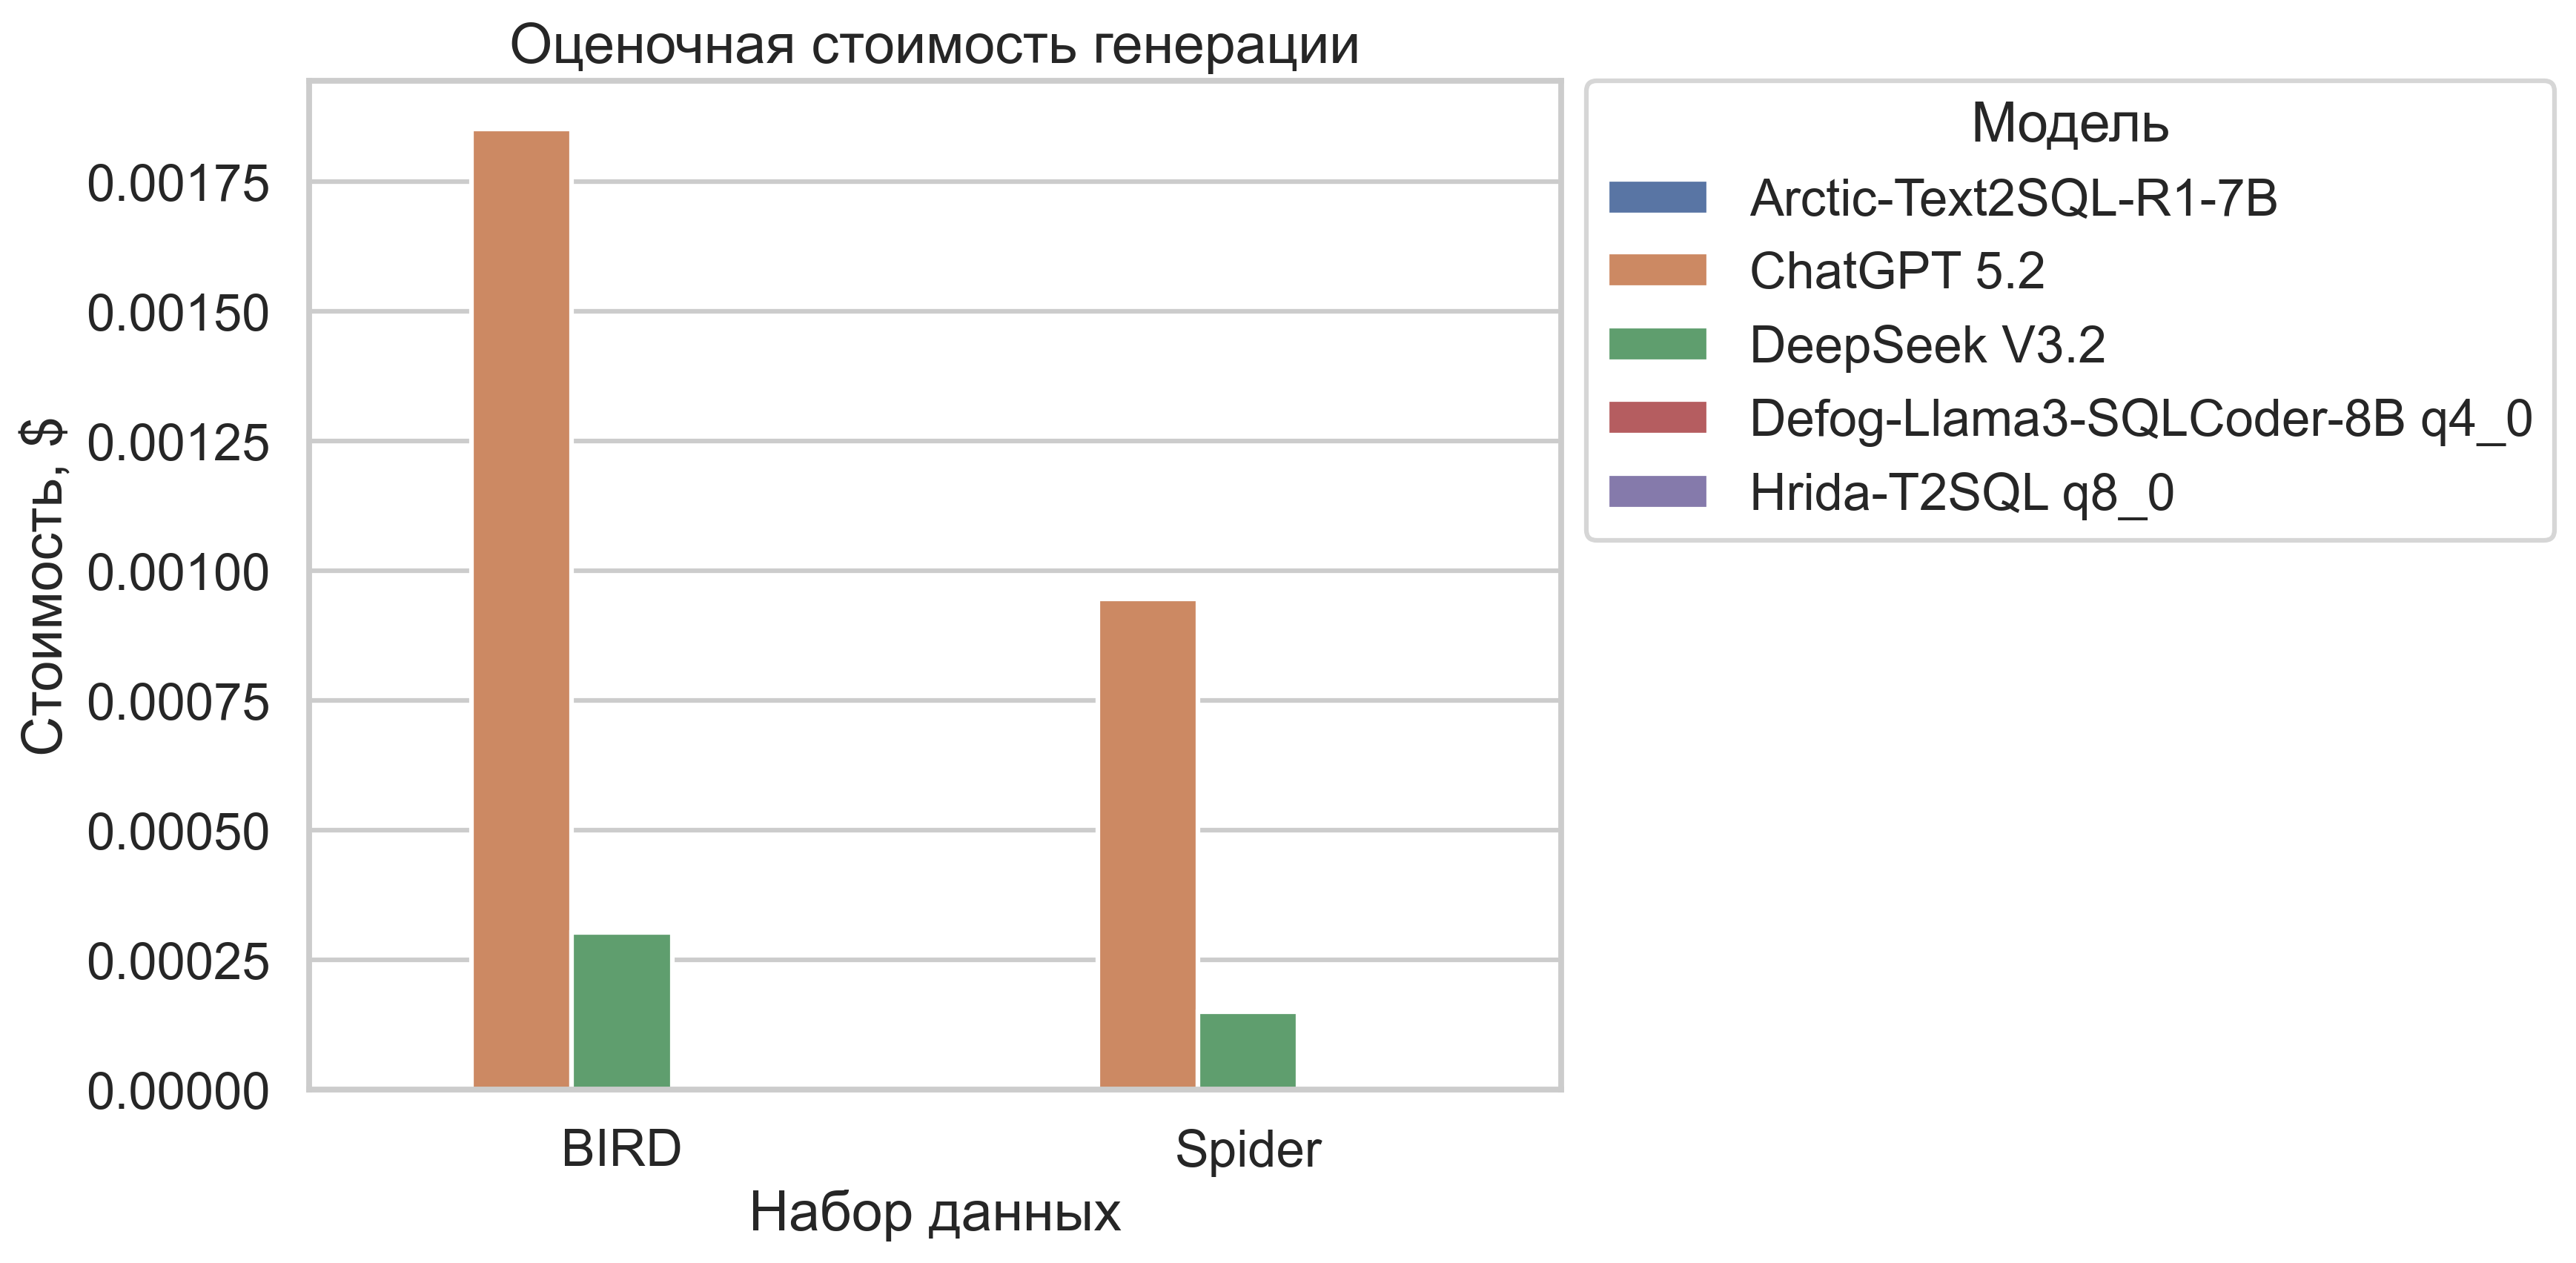

**Рисунок Г.6 — Парные различия качества в режиме Pass@K**

> Источник: `results/nl2sql/figures/pass_k/pairwise_delta_ru.png`

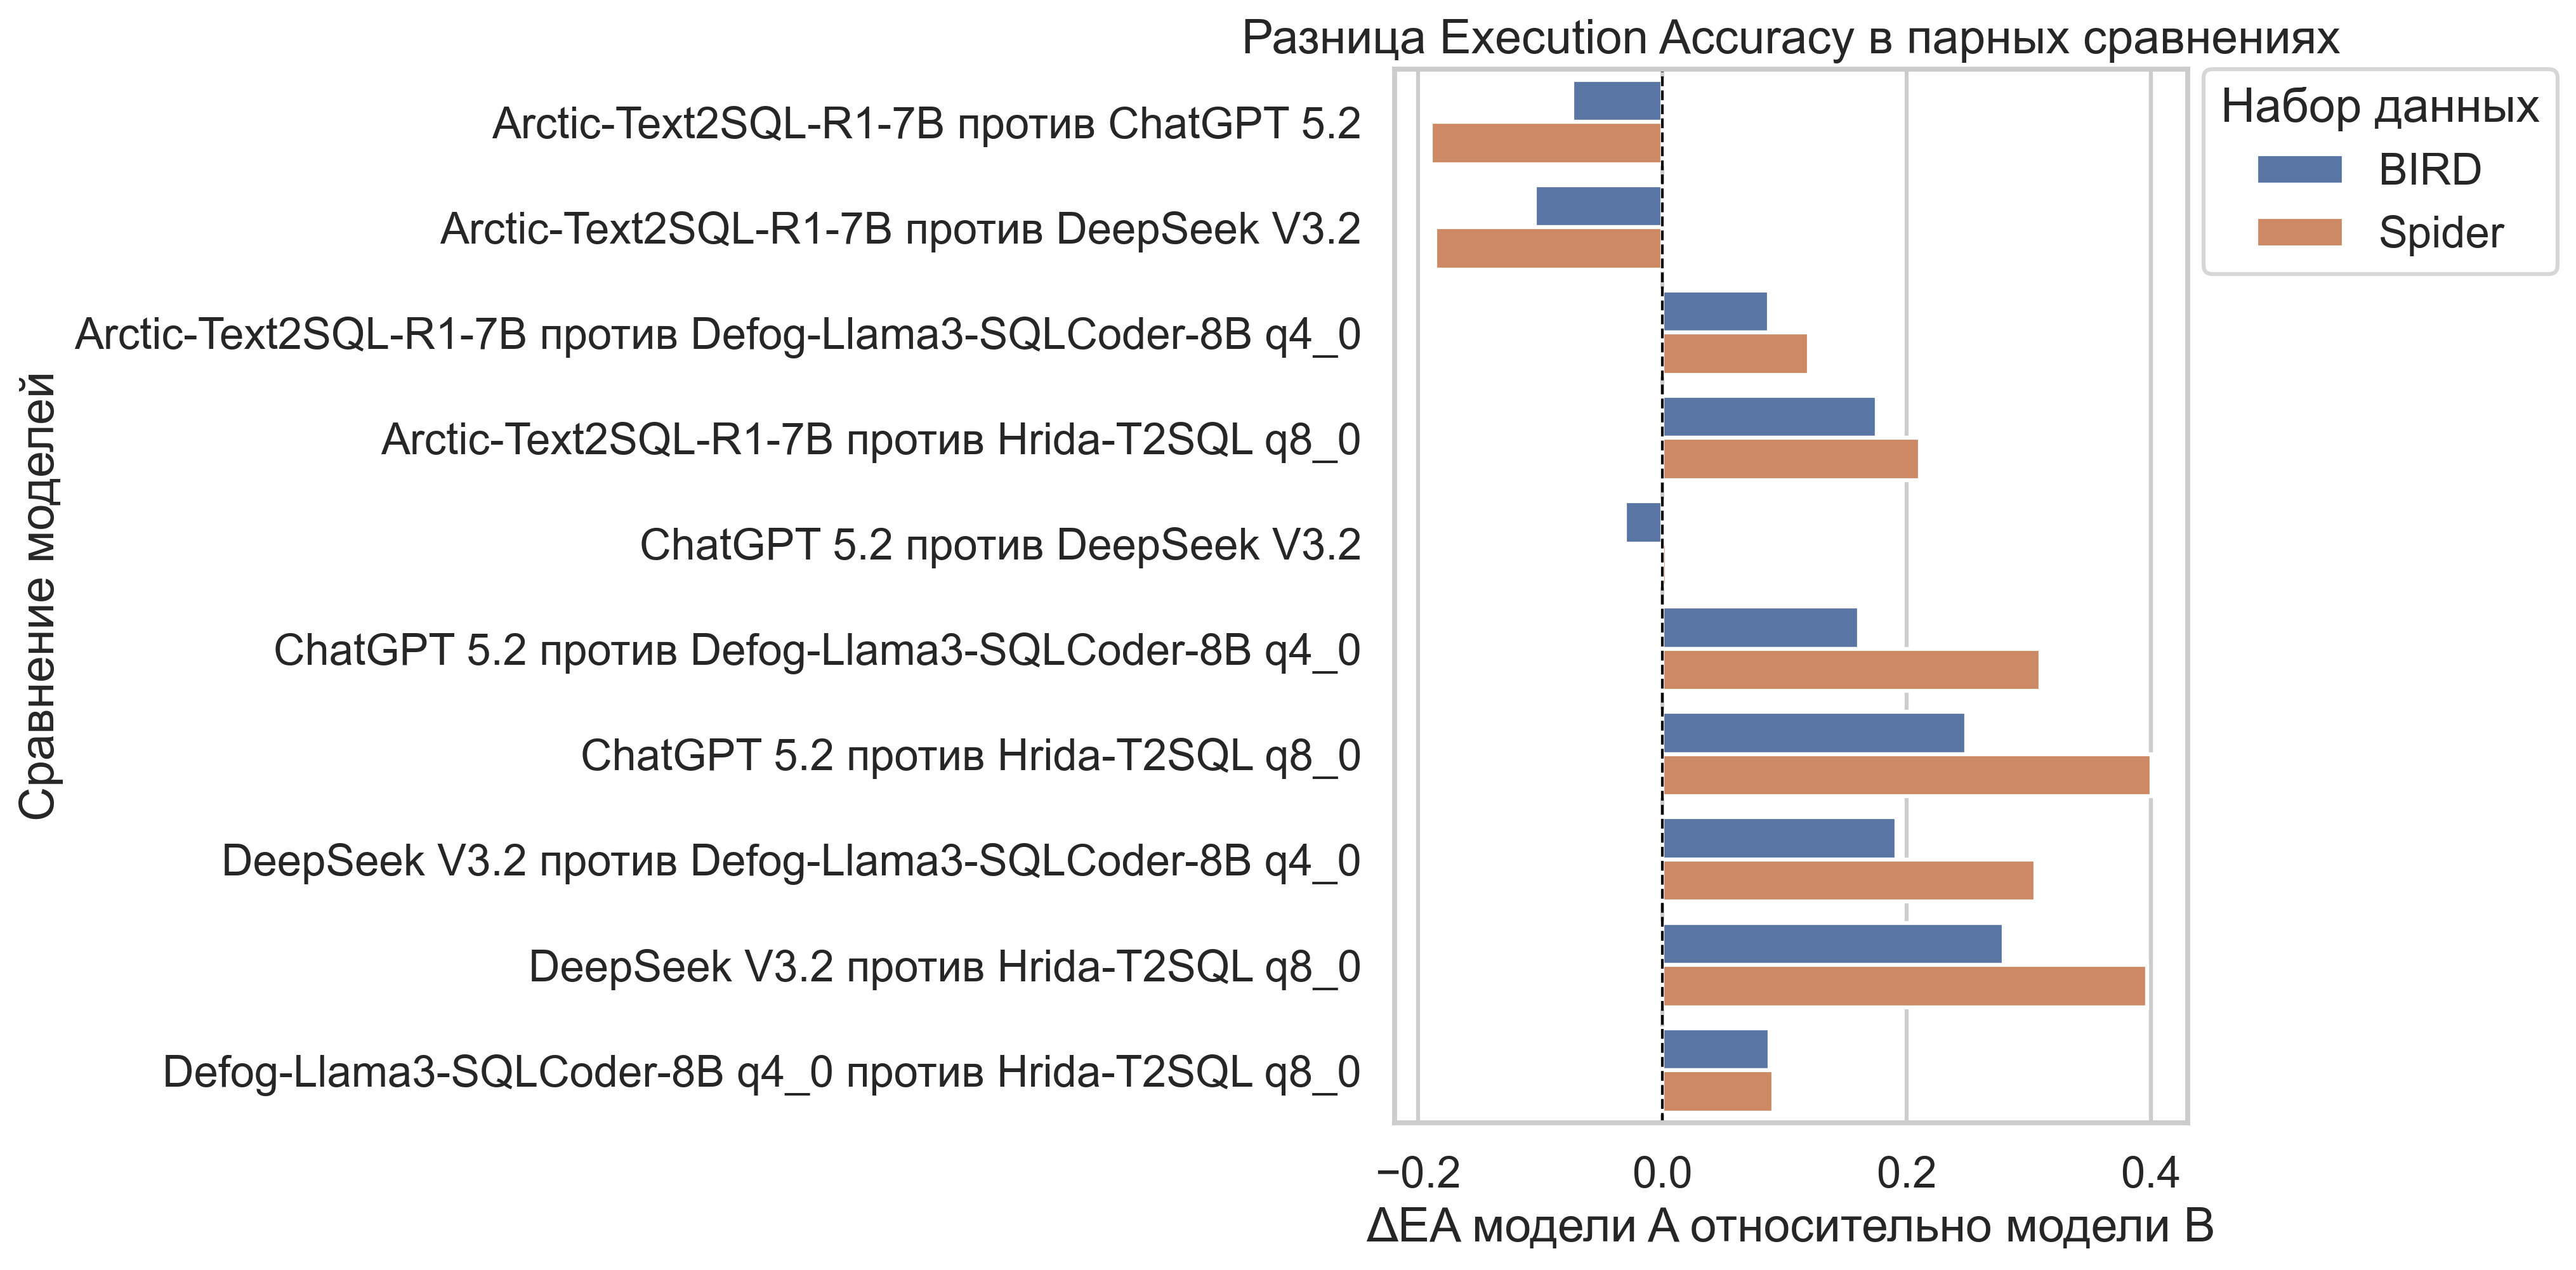

**Рисунок Г.7 — Pass@K и прирост Pass@5 относительно EA в SEB**

> Источник: `results/nl2sql/synthetic_benchmark/figures/synthetic_analysis/seb_passk_and_gain_ru.png`

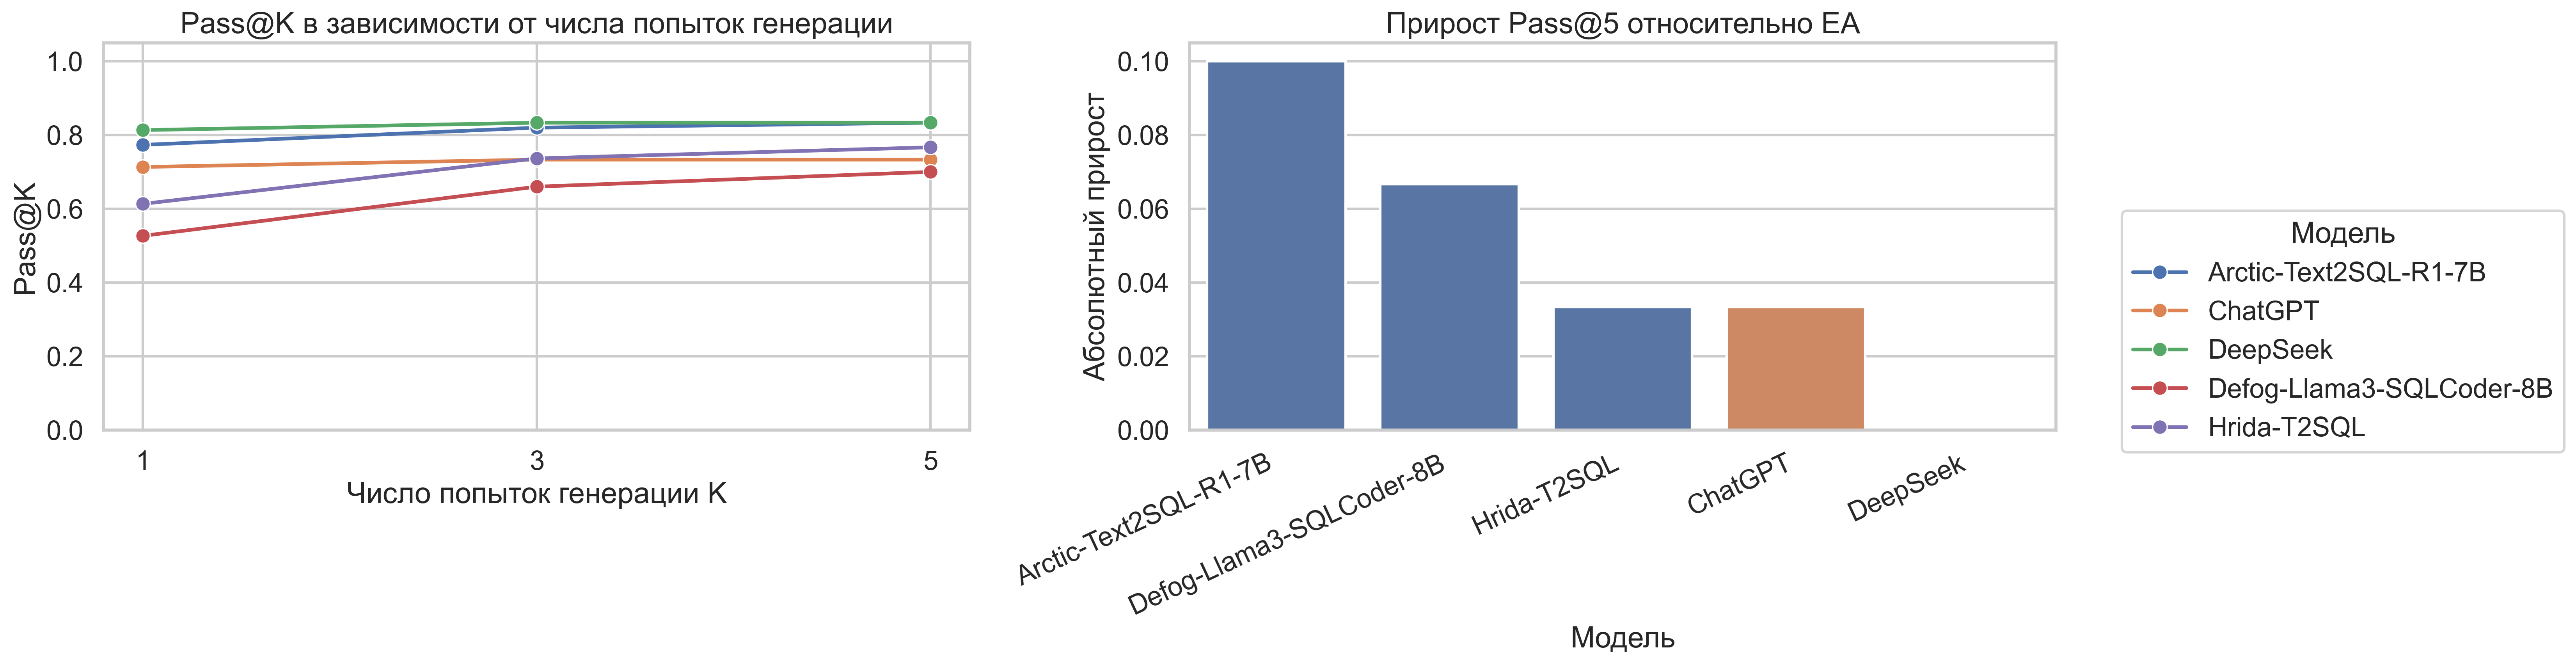

**Рисунок Г.8 — Pass@K по уровням сложности SEB**

> Источник: `results/nl2sql/synthetic_benchmark/figures/synthetic_analysis/seb_passk_difficulty_heatmap_ru.png`

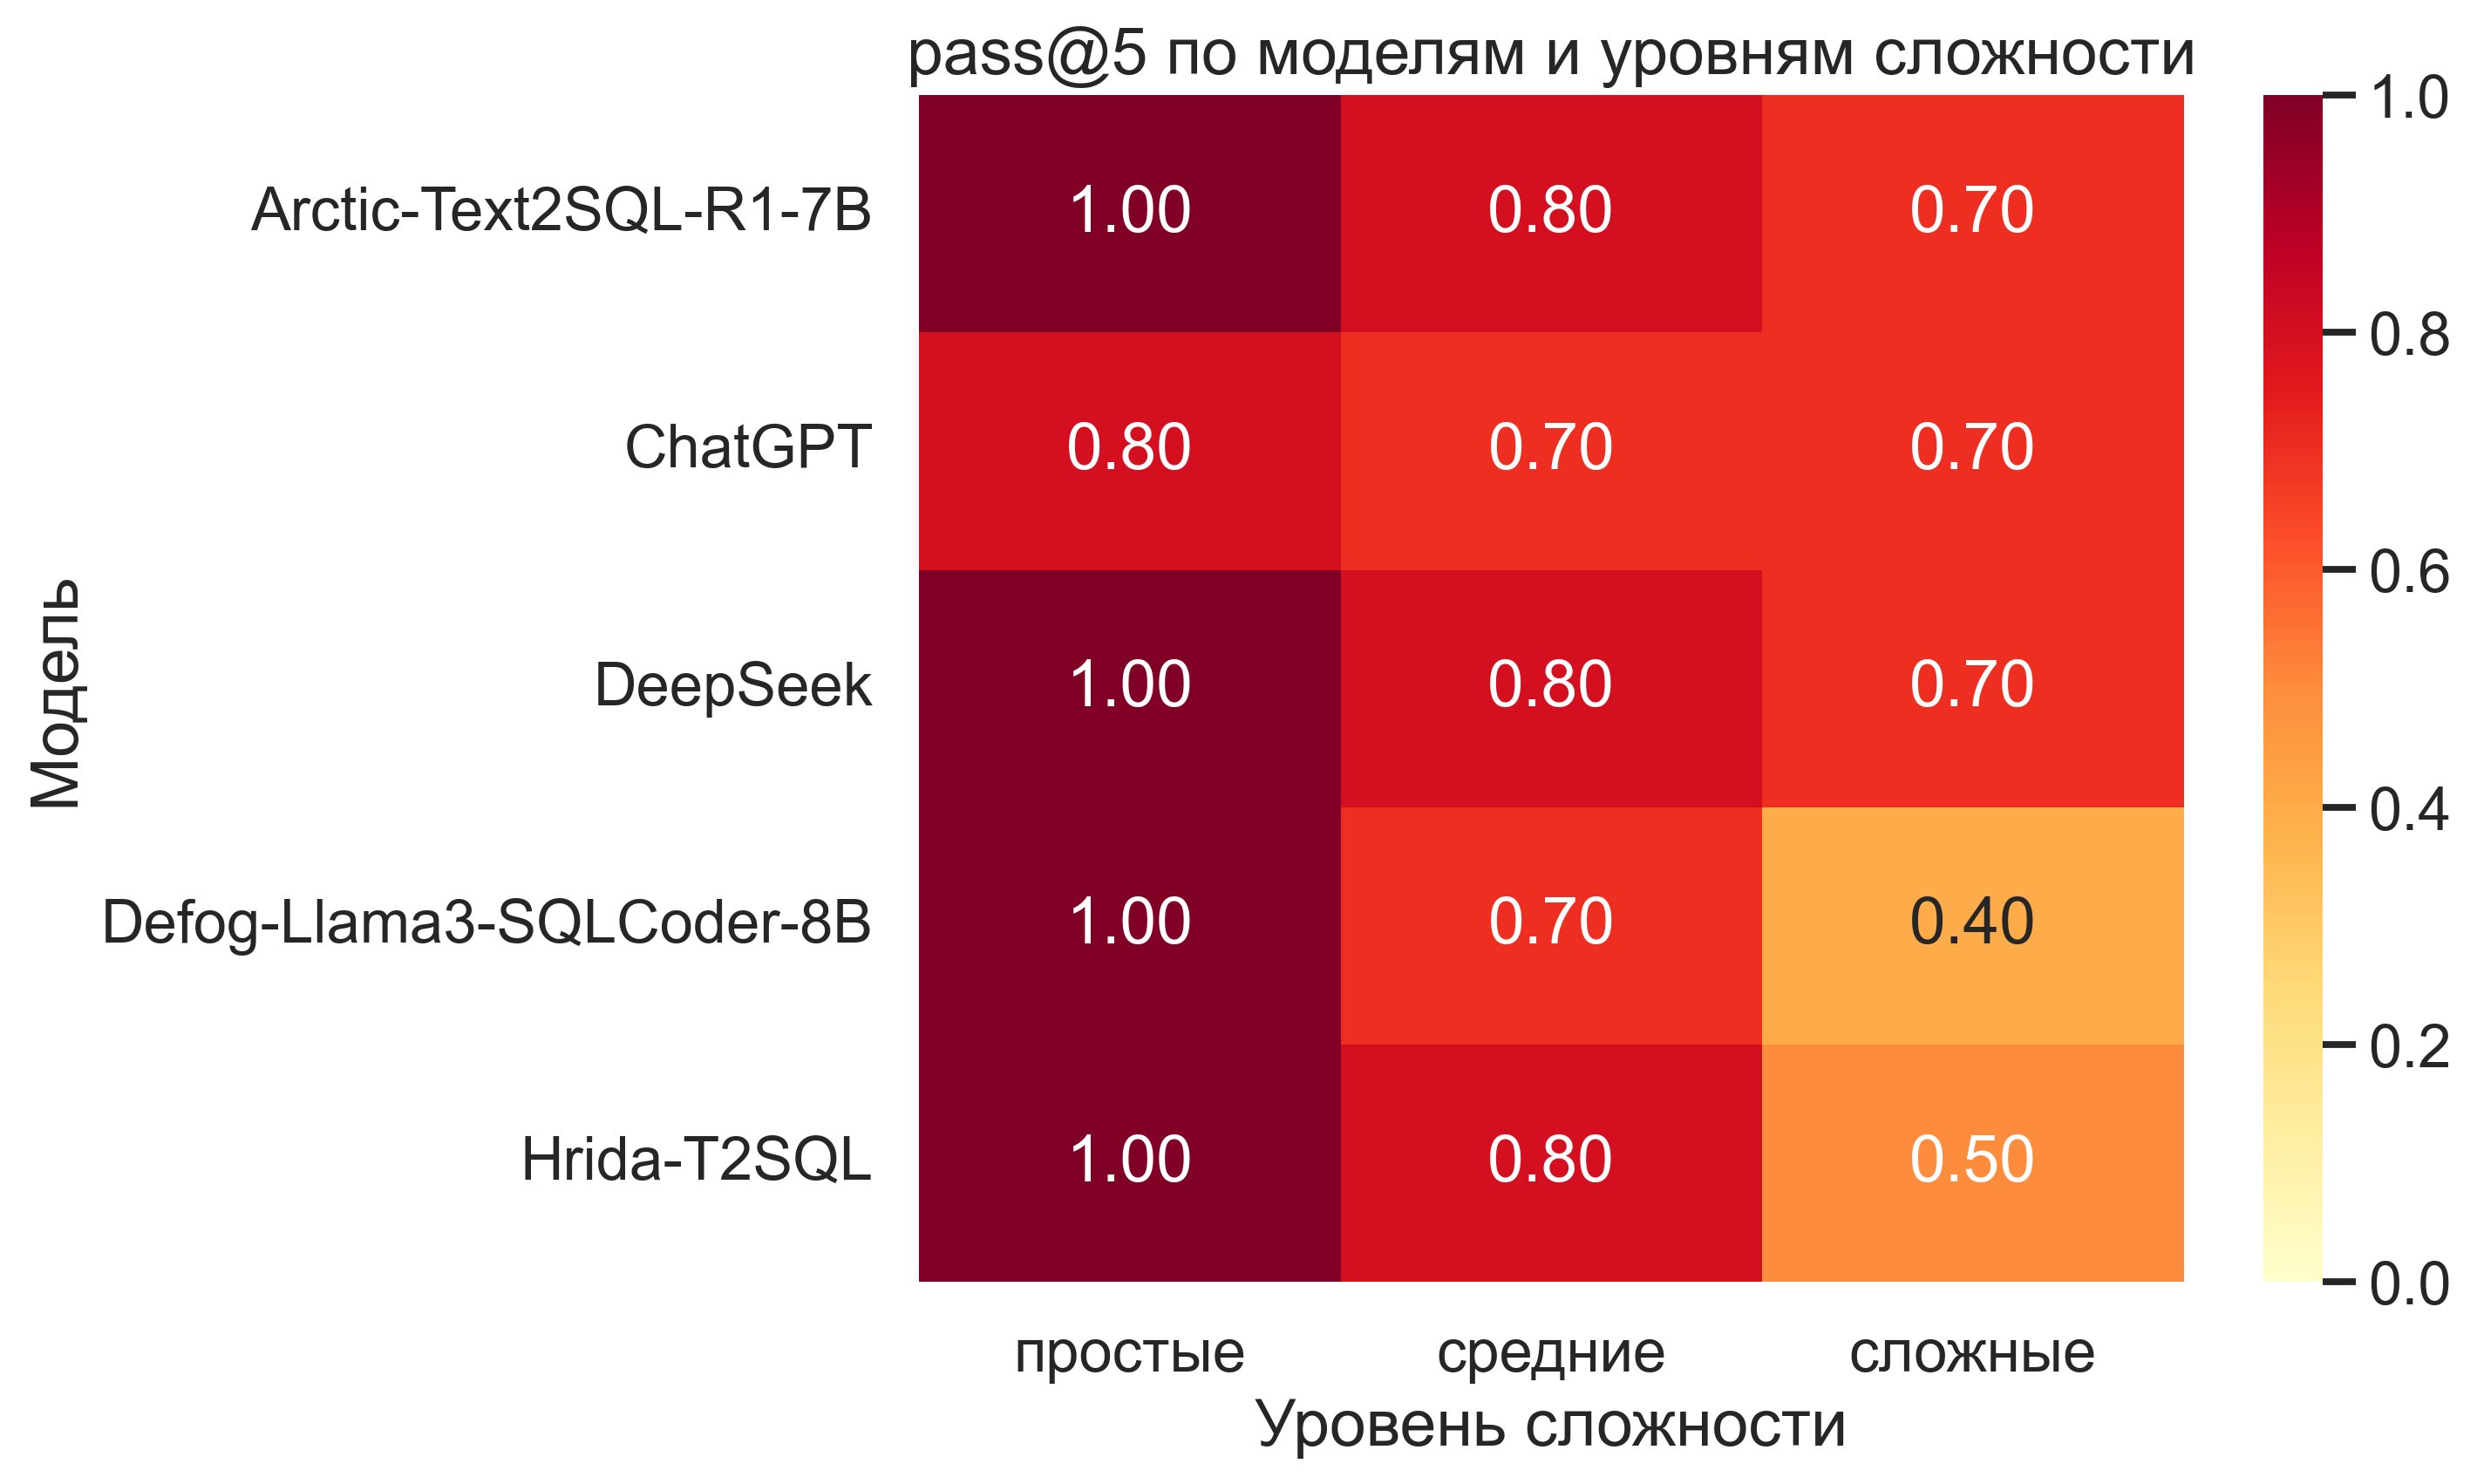

In [5]:
if pass_summary.empty:
    show_note('Pass@K summary отсутствует.')
else:
    pass_table = compact_metric_table(pass_summary, ['execution_accuracy', 'pass@1', 'pass@3', 'pass@5', 'Tinf', 'Tok', 'Cost'])
    pass_table = pass_table.sort_values(['Бенчмарк', 'Pass@5'], ascending=[True, False]).reset_index(drop=True)
    display_table('Таблица Г.1 — Полные результаты Pass@K по актуальным SQL-моделям', pass_table, 4)
    show_note(f'Количество строк в Pass@K-таблице: {len(pass_table)}. Ожидается 10 строк: 5 моделей x 2 бенчмарка.')

for title, fig in [
    ('Рисунок Г.1 — Число задач в наборах данных Pass@K', RESULTS_DIR / 'figures' / 'pass_k' / 'dataset_samples_ru.png'),
    ('Рисунок Г.2 — Распределение длины вопросов Pass@K', RESULTS_DIR / 'figures' / 'pass_k' / 'dataset_question_length_ru.png'),
    ('Рисунок Г.3 — Pass@K моделей на Spider и BIRD', RESULTS_DIR / 'figures' / 'pass_k' / 'passk_by_model_ru.png'),
    ('Рисунок Г.4 — Время инференса в режиме Pass@K', RESULTS_DIR / 'figures' / 'pass_k' / 'eff_latency_ru.png'),
    ('Рисунок Г.5 — Стоимость инференса в режиме Pass@K', RESULTS_DIR / 'figures' / 'pass_k' / 'eff_cost_ru.png'),
    ('Рисунок Г.6 — Парные различия качества в режиме Pass@K', RESULTS_DIR / 'figures' / 'pass_k' / 'pairwise_delta_ru.png'),
    ('Рисунок Г.7 — Pass@K и прирост Pass@5 относительно EA в SEB', RESULTS_DIR / 'synthetic_benchmark' / 'figures' / 'synthetic_analysis' / 'seb_passk_and_gain_ru.png'),
    ('Рисунок Г.8 — Pass@K по уровням сложности SEB', RESULTS_DIR / 'synthetic_benchmark' / 'figures' / 'synthetic_analysis' / 'seb_passk_difficulty_heatmap_ru.png'),
]:
    display_png(title, fig)


## Приложение Д. Дополнительные материалы по анализу ошибок и экспертному слою


**Таблица Д.1 — Структура исходов выполнения по моделям**

Модель,Бенчмарк,Категория,Количество
Arctic-Text2SQL-R1-7B,bird,correct,826
Arctic-Text2SQL-R1-7B,bird,execution_error,20
Arctic-Text2SQL-R1-7B,bird,wrong_result,688
ChatGPT 5.2,bird,correct,561
ChatGPT 5.2,bird,execution_error,8
ChatGPT 5.2,bird,wrong_result,965
Claude Sonnet 4.5,bird,correct,602
Claude Sonnet 4.5,bird,execution_error,39
Claude Sonnet 4.5,bird,wrong_result,893
DeepSeek V3.2,bird,correct,495


**Таблица Д.2 — Парные различия EA на общих примерах**

Бенчмарк,Сравнение,Общих примеров,EA left,EA right,Delta EA
bird,Arctic-Text2SQL-R1-7B vs Hrida-T2SQL q8_0,1534,0.538500,0.155100,0.383300
bird,Arctic-Text2SQL-R1-7B vs Defog-Llama3-SQLCoder-8B q4_0,1534,0.538500,0.263400,0.275100
bird,Claude Sonnet 4.5 vs Hrida-T2SQL q8_0,1534,0.392400,0.155100,0.237300
bird,Arctic-Text2SQL-R1-7B vs DeepSeek V3.2,1534,0.538500,0.322700,0.215800
bird,ChatGPT 5.2 vs Hrida-T2SQL q8_0,1534,0.365700,0.155100,0.210600
bird,Arctic-Text2SQL-R1-7B vs ChatGPT 5.2,1534,0.538500,0.365700,0.172800
bird,DeepSeek V3.2 vs Hrida-T2SQL q8_0,1534,0.322700,0.155100,0.167500
bird,Arctic-Text2SQL-R1-7B vs Claude Sonnet 4.5,1534,0.538500,0.392400,0.146000
bird,Claude Sonnet 4.5 vs Defog-Llama3-SQLCoder-8B q4_0,1534,0.392400,0.263400,0.129100
bird,Defog-Llama3-SQLCoder-8B q4_0 vs Hrida-T2SQL q8_0,1534,0.263400,0.155100,0.108200


**Таблица Д.3 — Примеры ошибок для ручного анализа**

sample_id,Бенчмарк,Модель,Сложность,SQL исполнился,Ошибка выполнения,Вопрос
bird_1,bird,Arctic-Text2SQL-R1-7B,moderate,True,nan,Please list the lowest three eligible free rates for students aged 5-17 in continuation schools.
bird_2,bird,Arctic-Text2SQL-R1-7B,simple,True,nan,Please list the zip code of all the charter schools in Fresno County Office of Education.
bird_4,bird,Arctic-Text2SQL-R1-7B,moderate,True,nan,Please list the phone numbers of the direct charter-funded schools that are opened after 2000/1/1.
bird_6,bird,Arctic-Text2SQL-R1-7B,simple,True,nan,"Among the schools with the SAT test takers of over 500, please list the schools that are magnet schools or offer a magnet program."
bird_9,bird,Arctic-Text2SQL-R1-7B,simple,True,nan,"Among the schools with the average score in Math over 560 in the SAT test, how many schools are directly charter-funded?"
bird_10,bird,Arctic-Text2SQL-R1-7B,simple,True,nan,"For the school with the highest average score in Reading in the SAT test, what is its FRPM count for students aged 5-17?"
bird_15,bird,Arctic-Text2SQL-R1-7B,simple,True,nan,Which active district has the highest average score in Reading?
bird_16,bird,Arctic-Text2SQL-R1-7B,simple,True,nan,How many schools in merged Alameda have number of test takers less than 100?
bird_17,bird,Arctic-Text2SQL-R1-7B,simple,True,nan,"Rank schools by their average score in Writing where the score is greater than 499, showing their charter numbers."
bird_18,bird,Arctic-Text2SQL-R1-7B,simple,True,nan,How many schools in Fresno (directly funded) have number of test takers not more than 250?


**Рисунок Д.1 — Категории ошибок в режиме EA**

> Источник: `results/nl2sql/figures/ea/error_categories_ru.png`

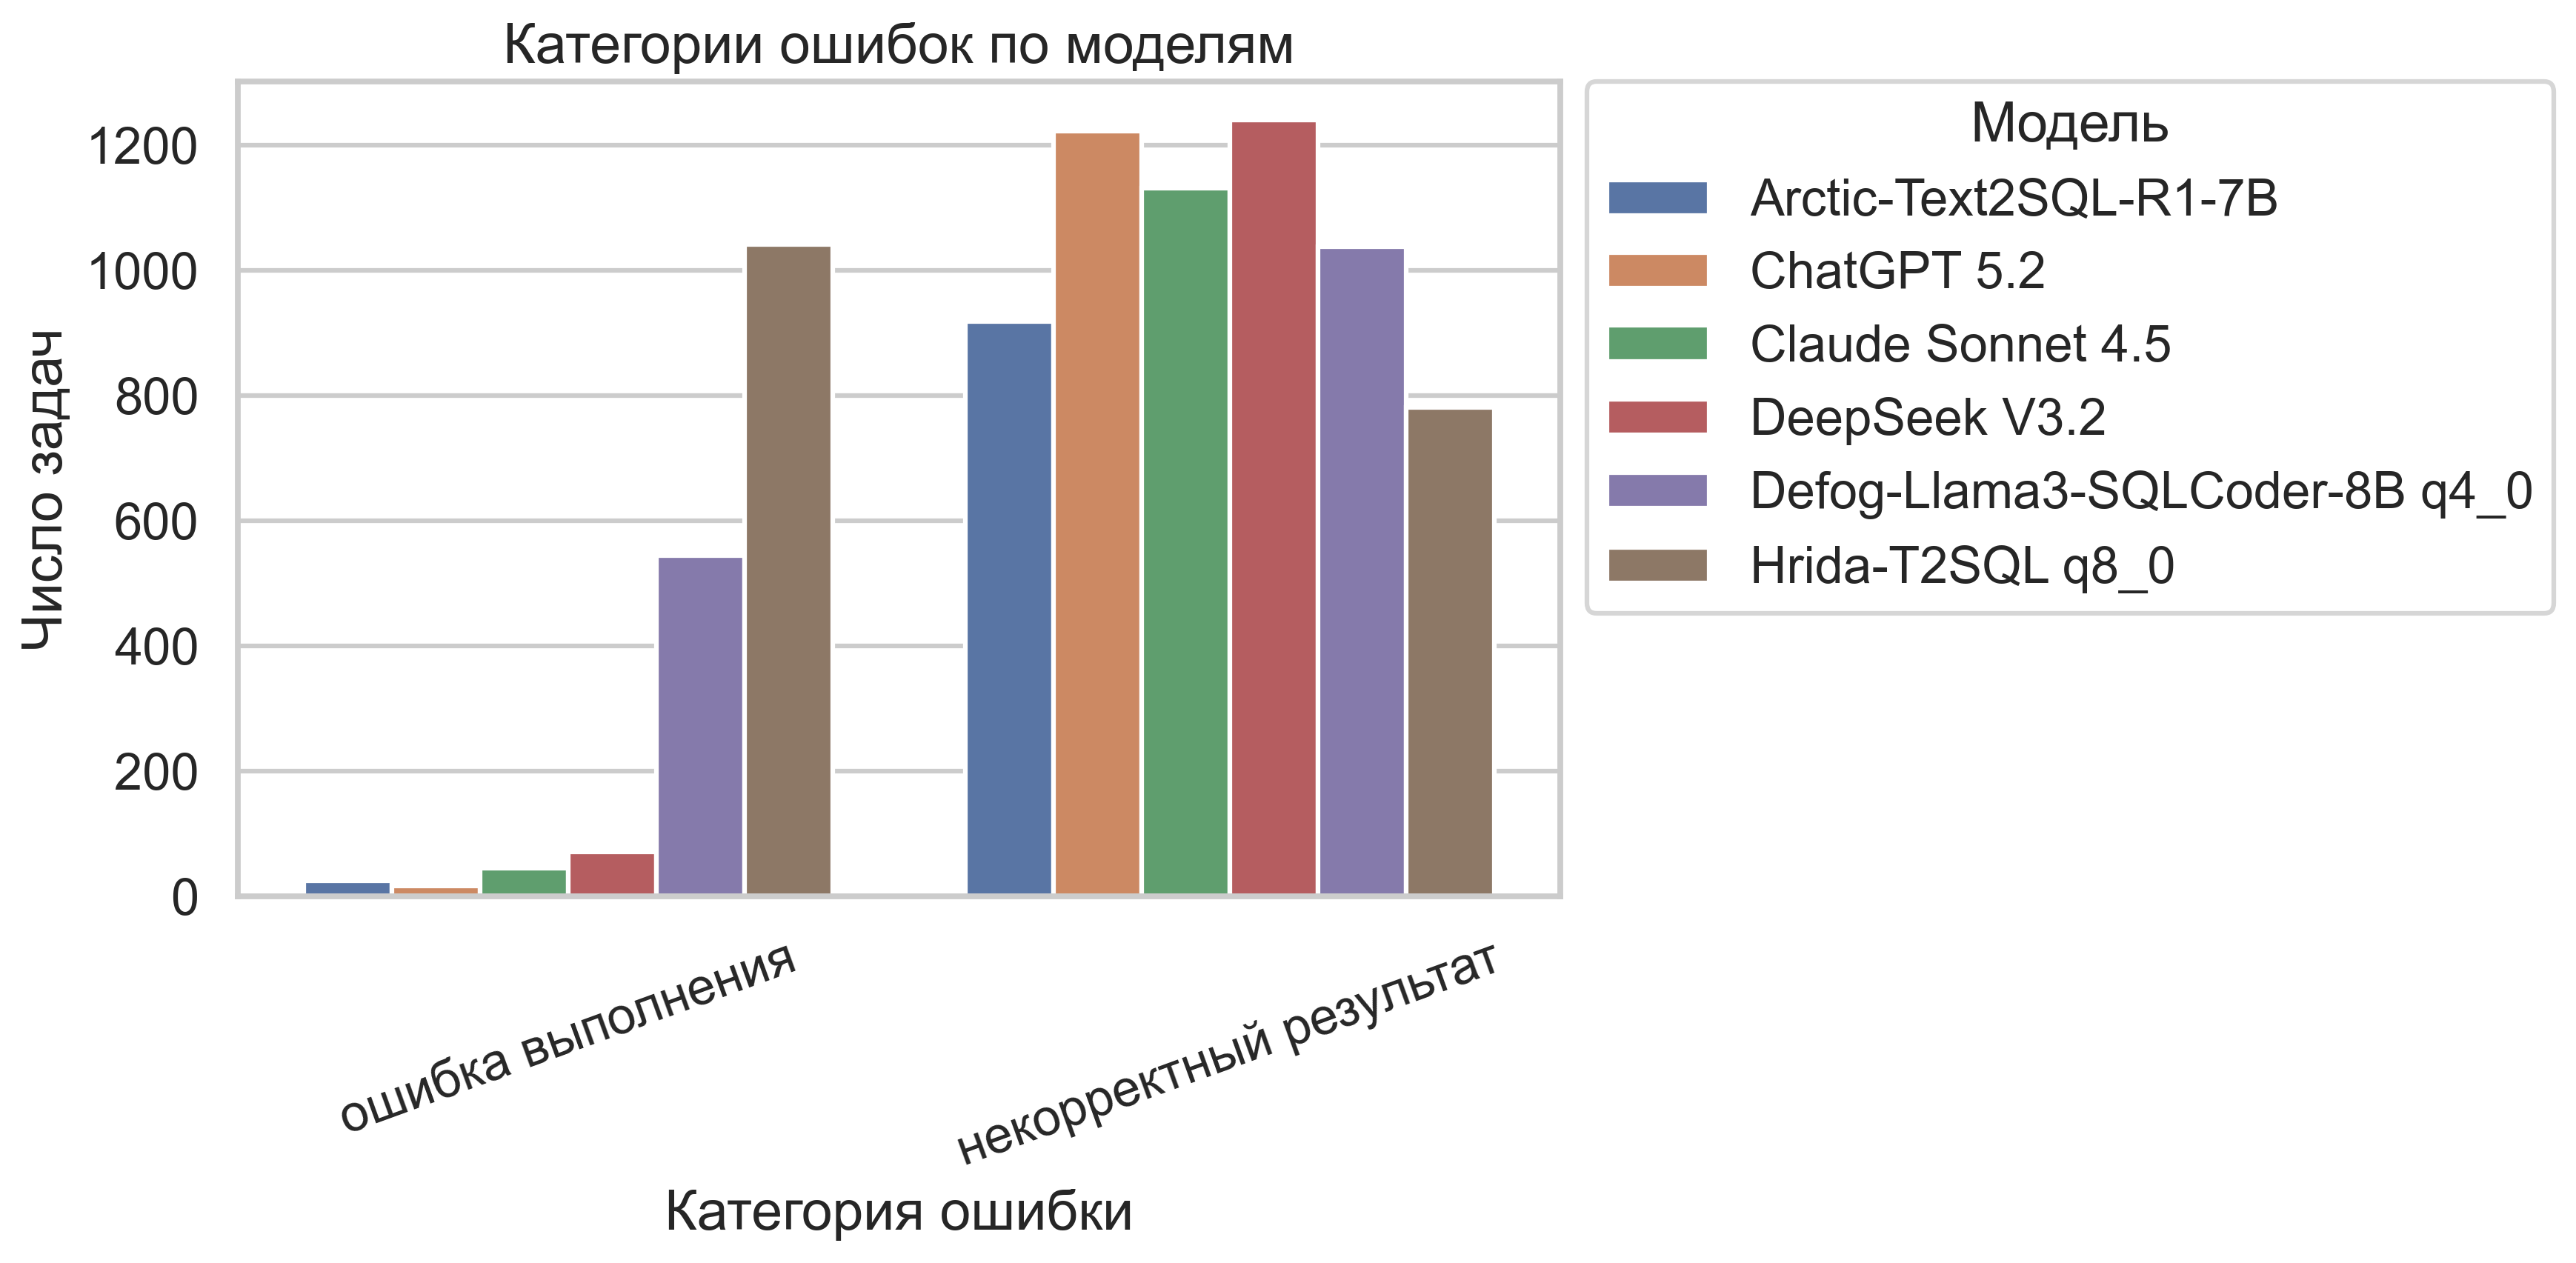

**Рисунок Д.2 — Пересечение корректных ответов в режиме EA**

> Источник: `results/nl2sql/figures/ea/correctness_overlap_ru.png`

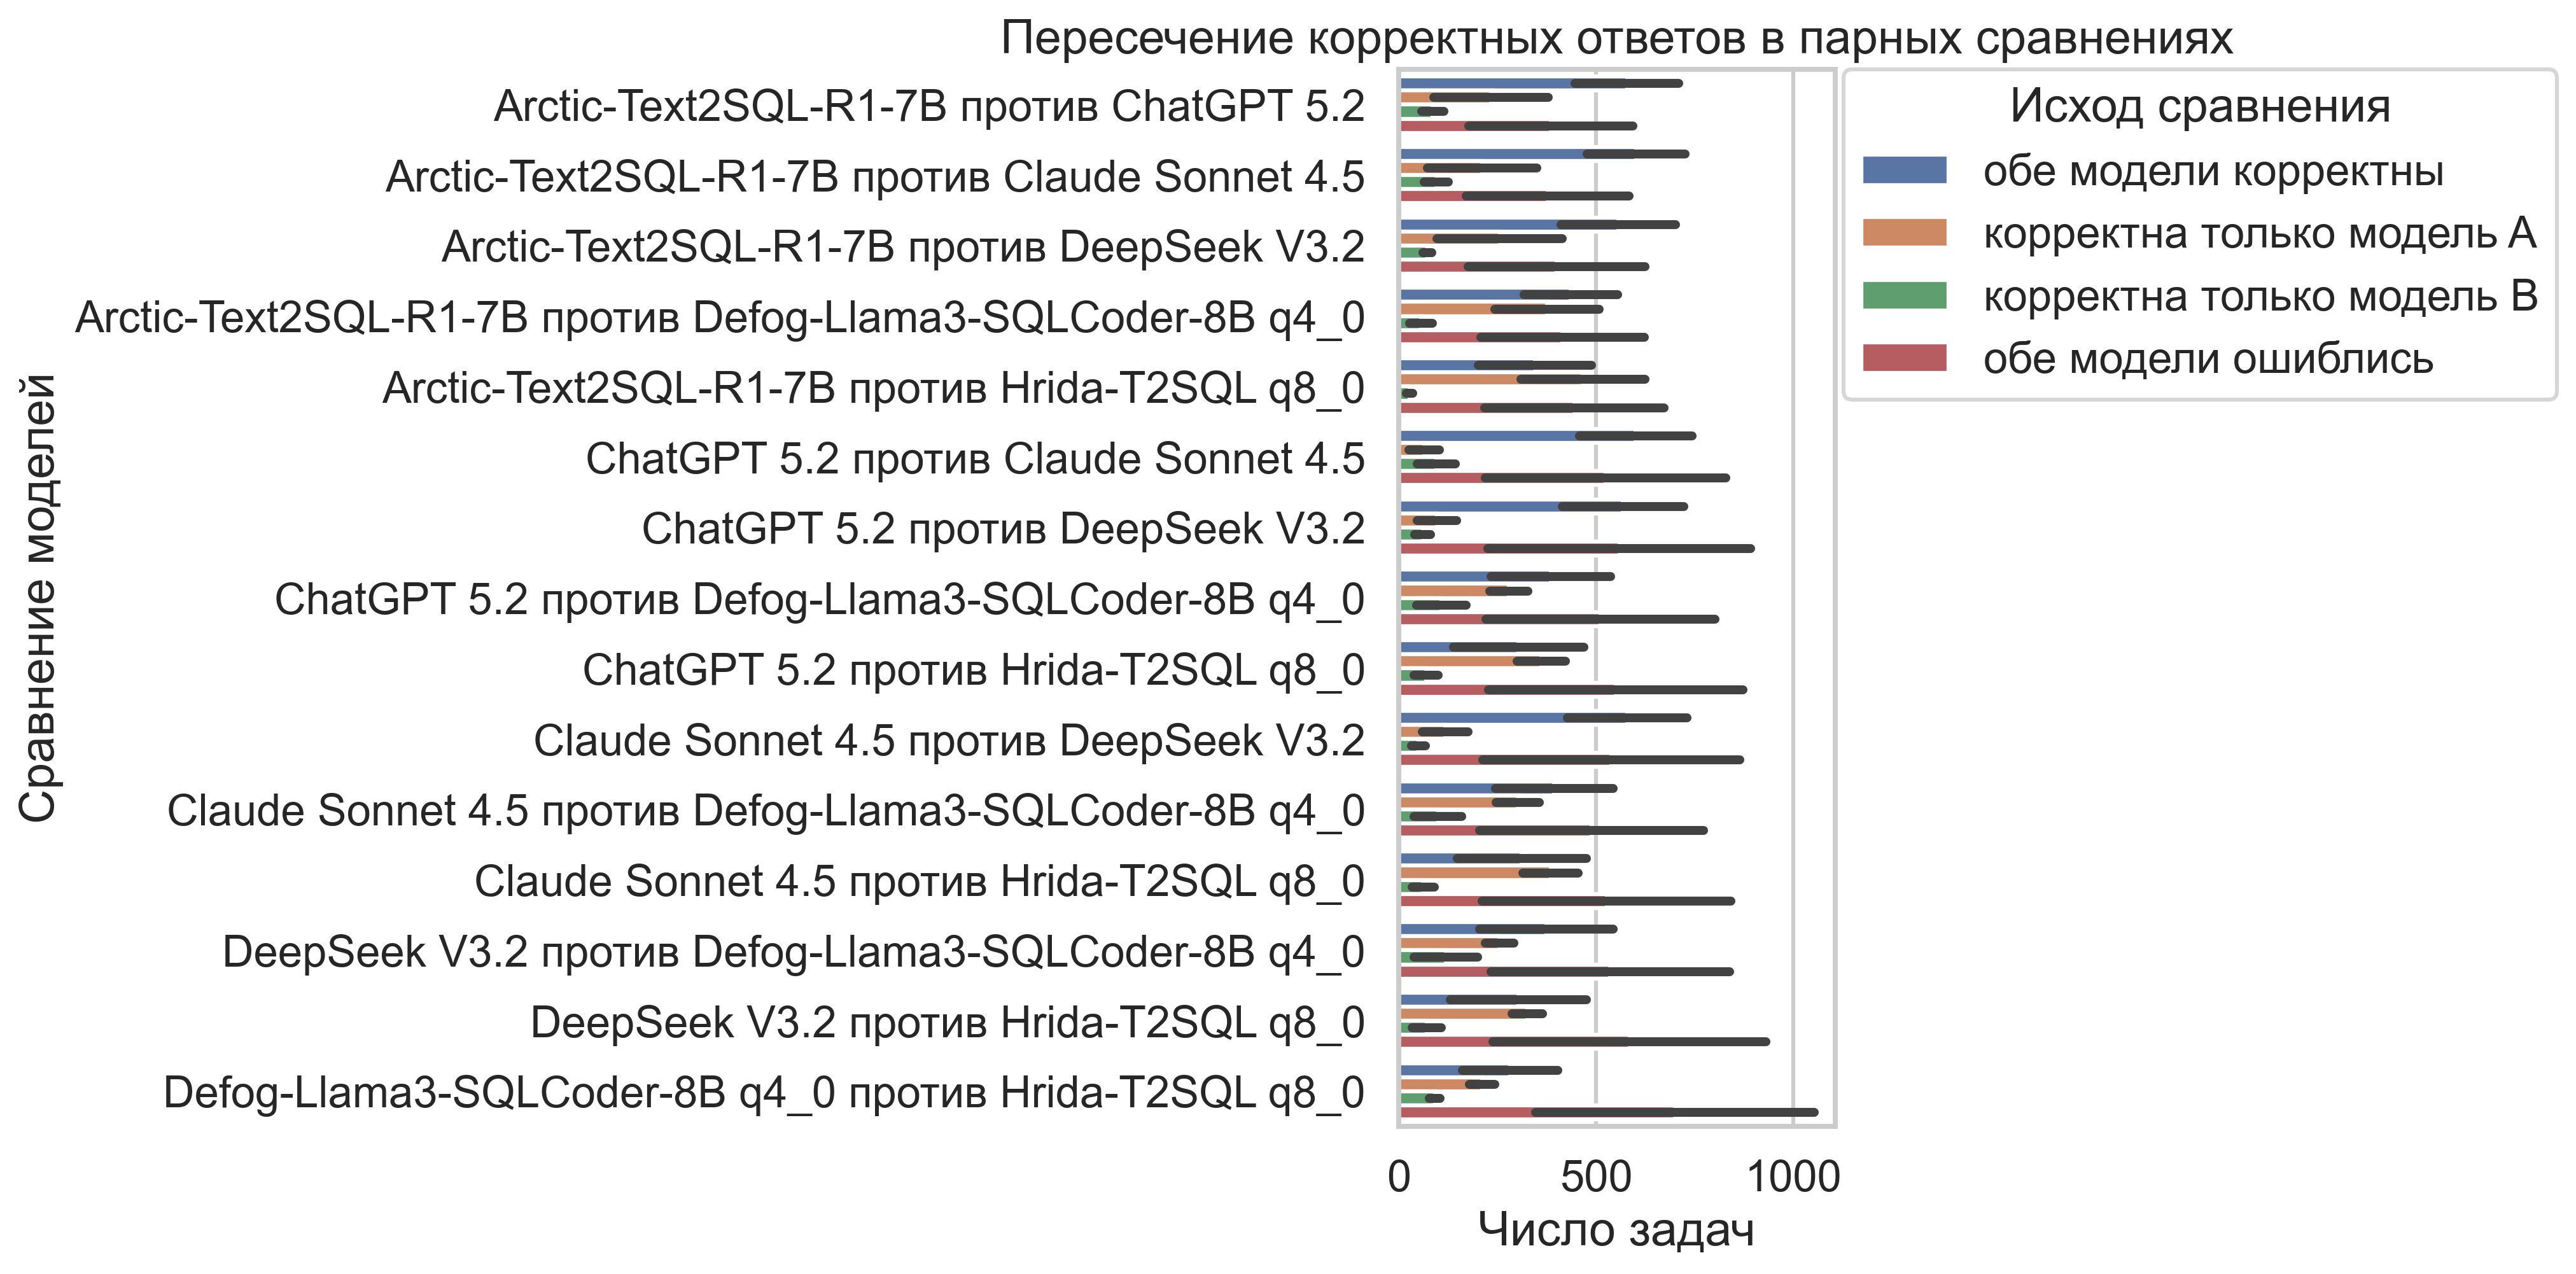

**Рисунок Д.3 — Диагностика сложности BIRD**

> Источник: `results/nl2sql/figures/final/final_bird_harder_diagnostics.png`

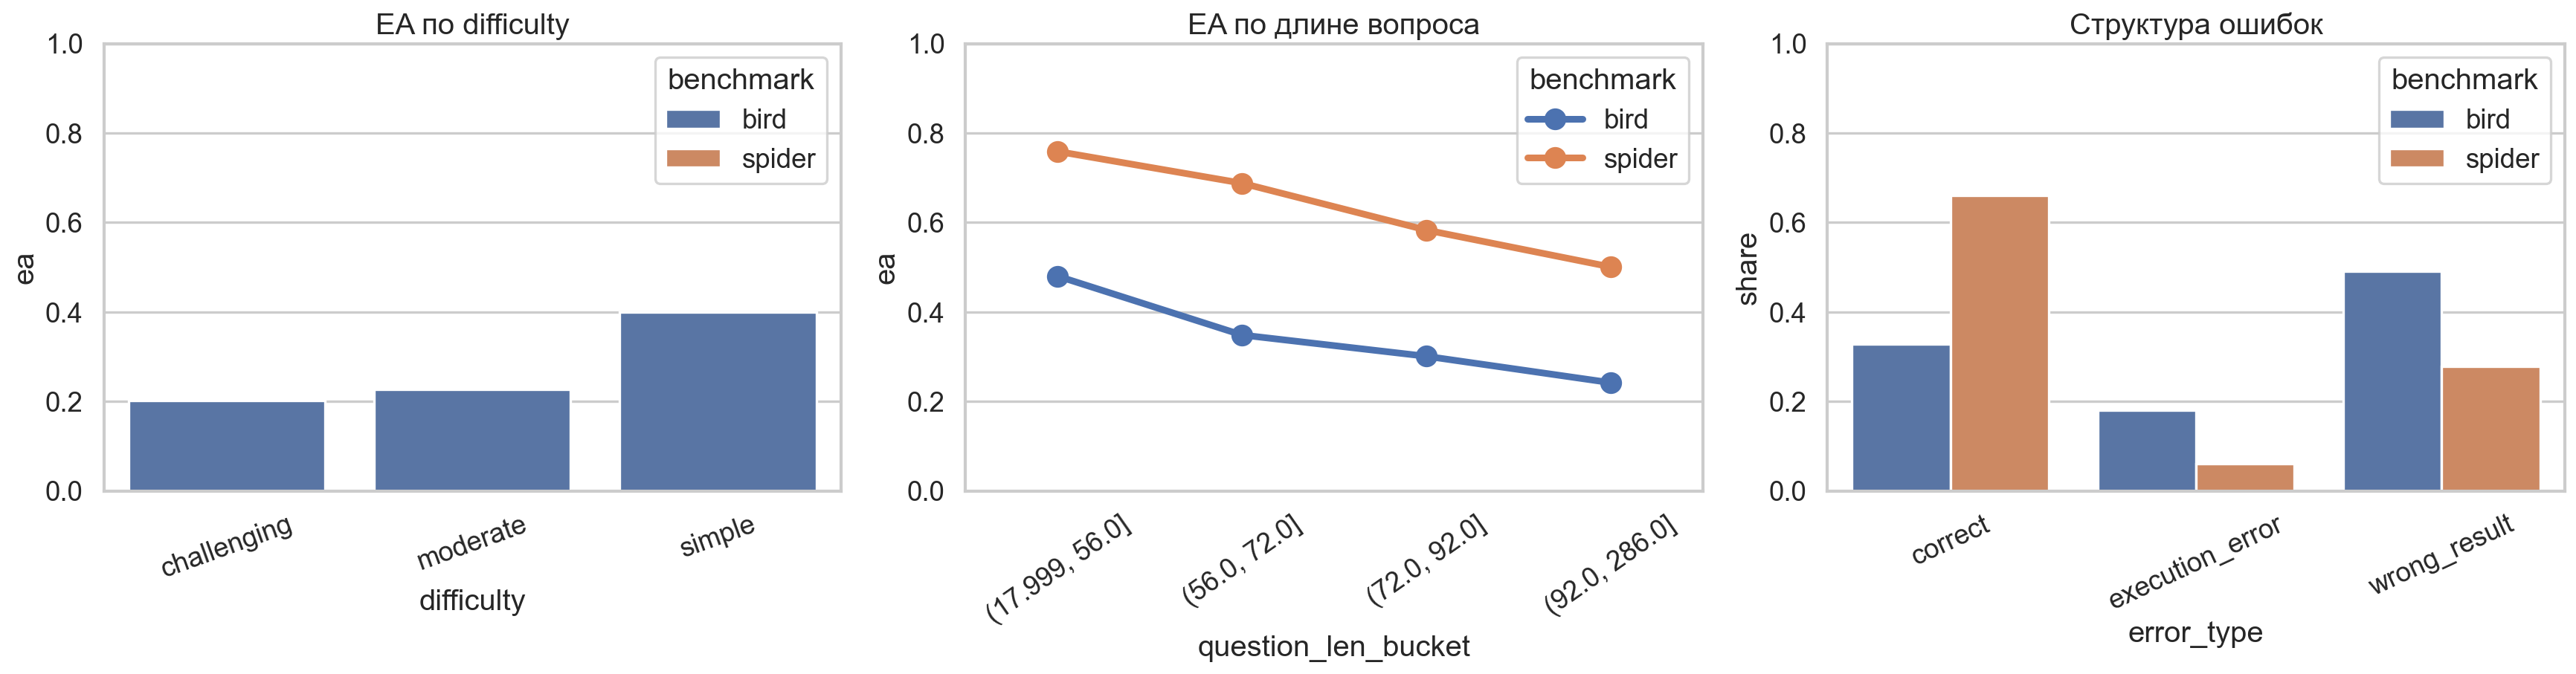

**Рисунок Д.4 — Распределение EA**

> Источник: `results/nl2sql/figures/final/final_ea_distribution.png`

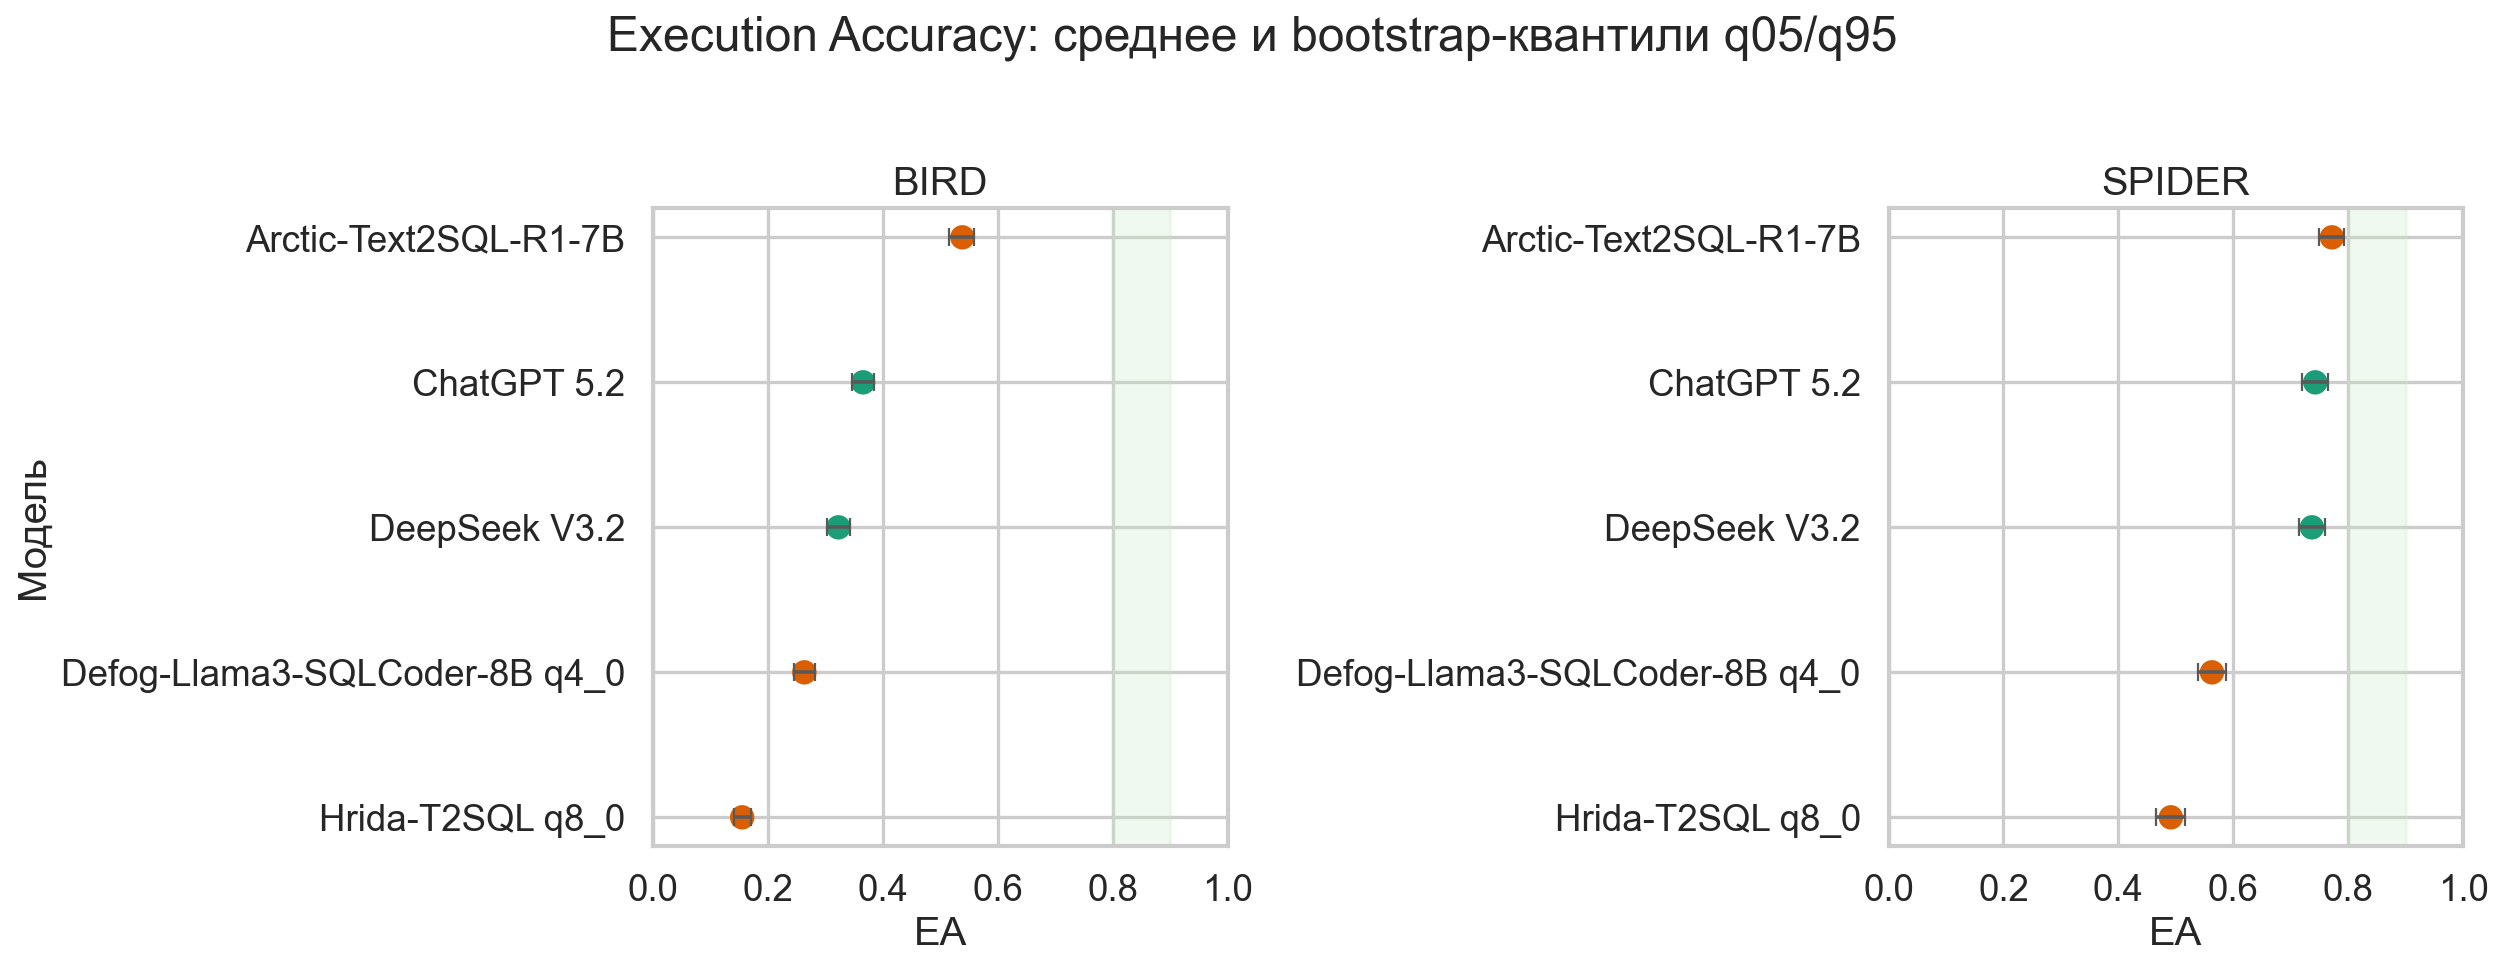

**Рисунок Д.5 — Парные различия EA**

> Источник: `results/nl2sql/figures/final/final_pairwise_delta_ea.png`

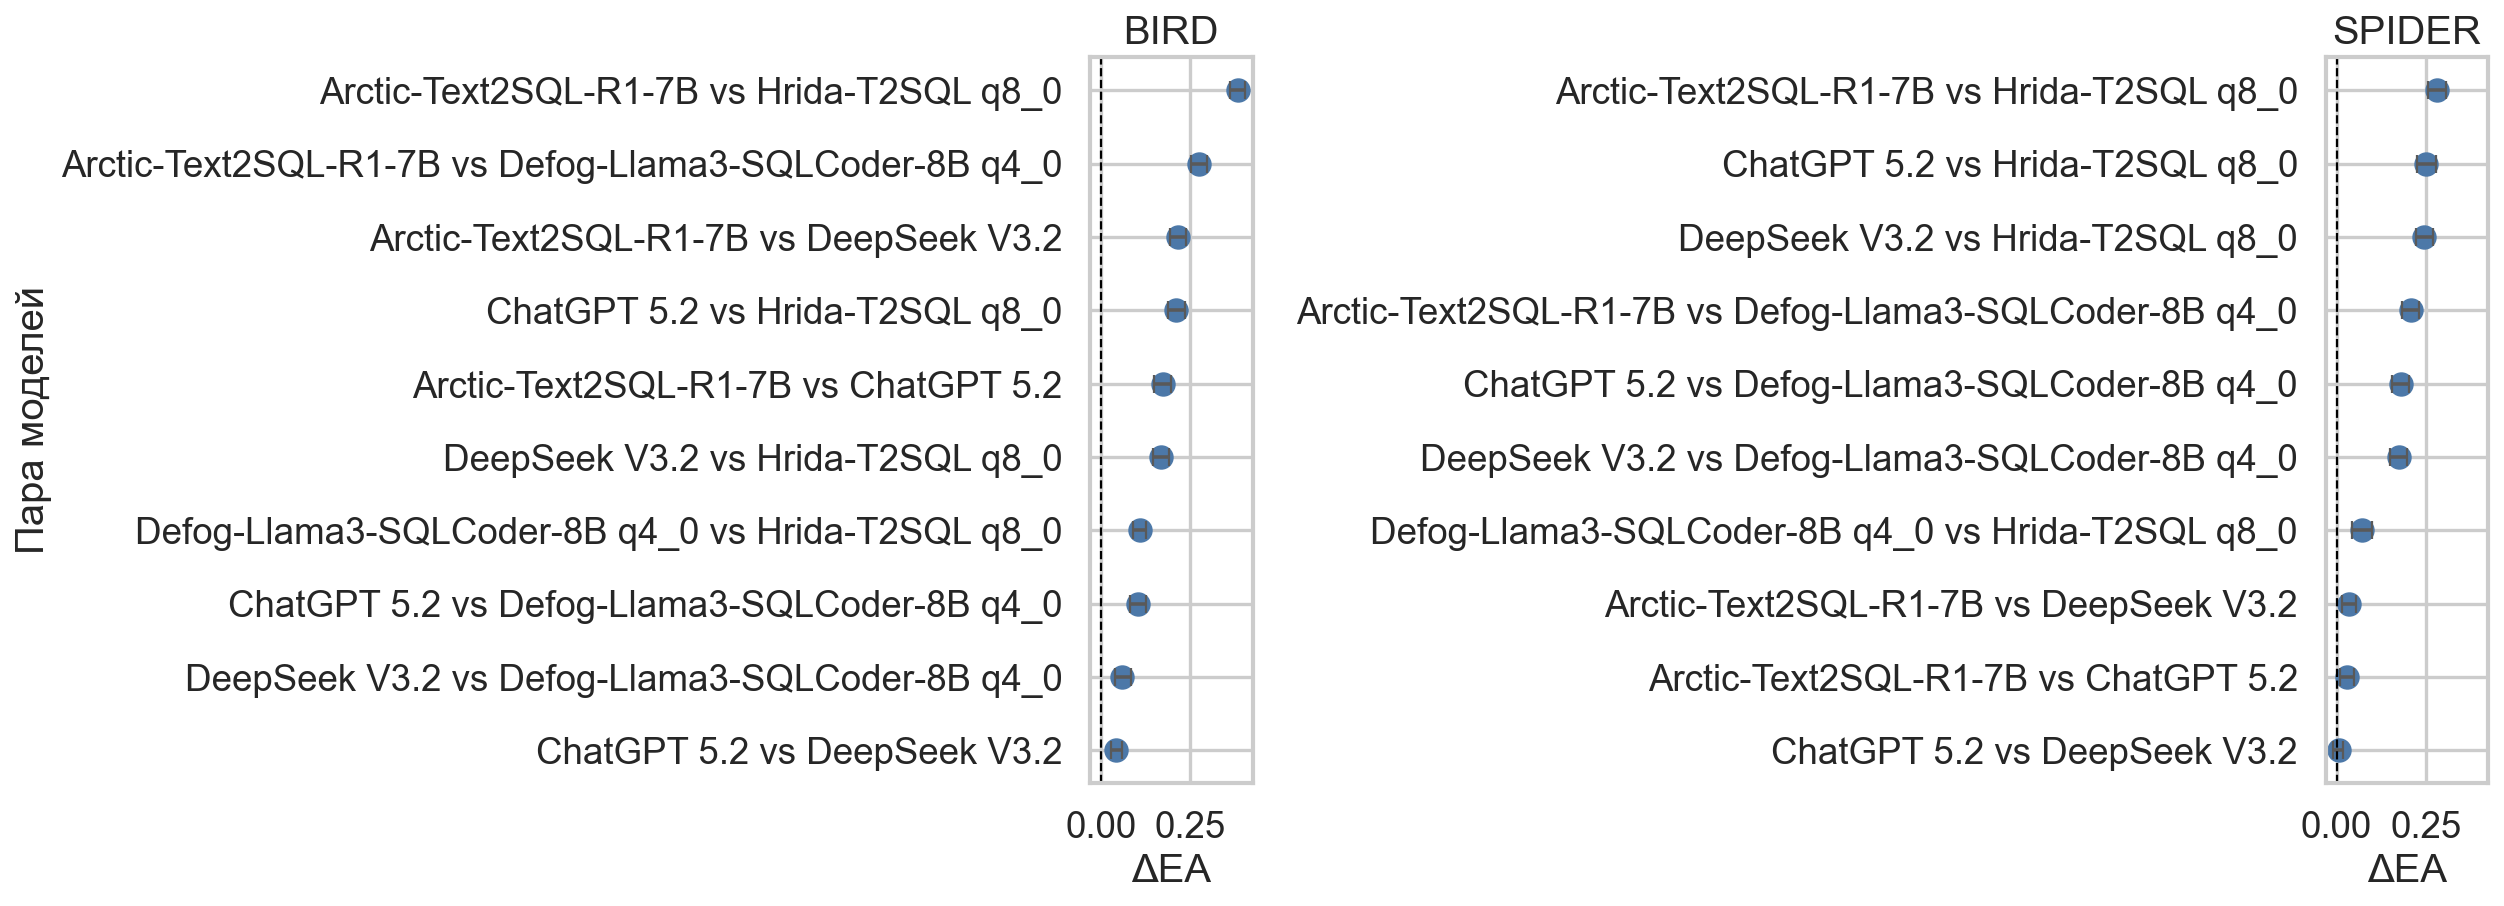

**Таблица Д.4 — Статус файлов экспертного слоя**

Файл,Статус,Интерпретация
results/nl2sql/metrics/ea/expert_scores_template.csv,шаблон существует,"Это шаблон для разметки, а не результат экспертного эксперимента."
results/nl2sql/metrics/pass_k/expert_scores_template.csv,шаблон существует,"Это шаблон для разметки, а не результат экспертного эксперимента."


> Графики expert_coverage из report-ноутбуков отражают заполненность шаблона экспертной разметки. Их не следует интерпретировать как самостоятельный количественный экспертный результат без отдельного протокола разметки.

In [6]:
if ea_samples.empty:
    show_note('EA sample metrics отсутствуют. Таблицы анализа ошибок не показаны.')
else:
    tmp = ea_samples.copy()
    tmp['Категория'] = tmp.apply(lambda row: 'correct' if bool(row.get('first_hit')) else ('execution_error' if not bool(row.get('first_pred_success')) else 'wrong_result'), axis=1)
    error_summary = tmp.groupby(['model_display_name', 'benchmark', 'Категория'], dropna=False).size().reset_index(name='Количество')
    error_summary = error_summary.rename(columns={'model_display_name': 'Модель', 'benchmark': 'Бенчмарк'}).sort_values(['Бенчмарк', 'Модель', 'Категория'])
    display_table('Таблица Д.1 — Структура исходов выполнения по моделям', error_summary)

    pivot = ea_samples.pivot_table(index=['benchmark', 'sample_id'], columns='model_display_name', values='first_hit', aggfunc='first')
    pair_rows = []
    models = sorted([col for col in pivot.columns if pd.notna(col)])
    for benchmark in sorted(ea_samples['benchmark'].dropna().unique()):
        bench_pivot = pivot.loc[benchmark] if benchmark in pivot.index.get_level_values(0) else pd.DataFrame()
        for i, left in enumerate(models):
            for right in models[i + 1:]:
                if left not in bench_pivot.columns or right not in bench_pivot.columns:
                    continue
                pair = bench_pivot[[left, right]].dropna().astype(bool)
                if pair.empty:
                    continue
                pair_rows.append({'Бенчмарк': benchmark, 'Сравнение': f'{left} vs {right}', 'Общих примеров': len(pair), 'EA left': pair[left].mean(), 'EA right': pair[right].mean(), 'Delta EA': pair[left].mean() - pair[right].mean()})
    pairwise_df = pd.DataFrame(pair_rows).sort_values(['Бенчмарк', 'Delta EA'], ascending=[True, False])
    display_table('Таблица Д.2 — Парные различия EA на общих примерах', pairwise_df, 4)

    failure_examples = ea_samples[(~ea_samples['first_hit'].fillna(False).astype(bool))][['sample_id', 'benchmark', 'model_display_name', 'difficulty', 'first_pred_success', 'first_pred_error', 'question']].head(20)
    failure_examples = failure_examples.rename(columns={'benchmark': 'Бенчмарк', 'model_display_name': 'Модель', 'difficulty': 'Сложность', 'first_pred_success': 'SQL исполнился', 'first_pred_error': 'Ошибка выполнения', 'question': 'Вопрос'})
    display_table('Таблица Д.3 — Примеры ошибок для ручного анализа', failure_examples)

for title, fig in [
    ('Рисунок Д.1 — Категории ошибок в режиме EA', RESULTS_DIR / 'figures' / 'ea' / 'error_categories_ru.png'),
    ('Рисунок Д.2 — Пересечение корректных ответов в режиме EA', RESULTS_DIR / 'figures' / 'ea' / 'correctness_overlap_ru.png'),
    ('Рисунок Д.3 — Диагностика сложности BIRD', RESULTS_DIR / 'figures' / 'final' / 'final_bird_harder_diagnostics.png'),
    ('Рисунок Д.4 — Распределение EA', RESULTS_DIR / 'figures' / 'final' / 'final_ea_distribution.png'),
    ('Рисунок Д.5 — Парные различия EA', RESULTS_DIR / 'figures' / 'final' / 'final_pairwise_delta_ea.png'),
]:
    display_png(title, fig)

expert_note_df = pd.DataFrame([
    {'Файл': rel(path), 'Статус': 'шаблон существует' if path.exists() else 'файл отсутствует', 'Интерпретация': 'Это шаблон для разметки, а не результат экспертного эксперимента.'}
    for path in [RESULTS_DIR / 'metrics' / 'ea' / 'expert_scores_template.csv', RESULTS_DIR / 'metrics' / 'pass_k' / 'expert_scores_template.csv']
])
display_table('Таблица Д.4 — Статус файлов экспертного слоя', expert_note_df)
show_note('Графики expert_coverage из report-ноутбуков отражают заполненность шаблона экспертной разметки. Их не следует интерпретировать как самостоятельный количественный экспертный результат без отдельного протокола разметки.')


## Краткая памятка по переносу в Word

- Для основного текста лучше брать компактные итоговые таблицы `EA`/`Pass@K` и ключевые графики с русскими подписями.
- Для приложений можно переносить расширенные таблицы из соответствующих разделов этого ноутбука.
- `expert_scores_template.csv` является техническим шаблоном, а не результатом экспертной оценки; использовать его как количественный результат нельзя.
